## Часть 2. Работа с MLPClassifier

### <font color='#F5DEB3'> Подготовка обработанного датасета

In [3]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yaml

In [4]:
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_processed': 'data/processed', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [5]:
processed_path = os.path.join(config['data']['dataset_processed'], 'Data_Set_AB_processed.xlsx')

V13 = pd.read_excel(processed_path)

In [6]:
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

### <font color='#F5DEB3'>Задание №1

1. Для выполнения практикума рекомендуется использовать полносвязную нейронную сеть прямого распространения – **MLPClassifier** из библиотеки машинного обучения sklearn.
2. Провести небольшую предварительную серию экспериментов с параметрами *“hidden_layer_sizes”*, *“activation”*, *“solver”* и *“max_iter”*, добиваясь наиболее близких между собой значений **критерия кросс-валидации** (перекрестного критерия ошибки) на обучающей выборке (Data Set_Train).
3. **Необходимо добиться** в режиме работы «на результат» как можно более высокой точности прогнозирования выходной величины в зависимости от гиперпараметров.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

import ast

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
def train_models(
    data_x, data_y,
    hidden_options,
    activation_options,
    solver_options,
    max_iter_options,
    random_state,
    cv_folds
):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    results = []
    combo_id = 0

    for hls in hidden_options:
        for act in activation_options:
            for solv in solver_options:
                for max_it in max_iter_options:
                    combo_id += 1
                    mlp = MLPClassifier(
                        hidden_layer_sizes=hls,
                        activation=act,
                        solver=solv,
                        max_iter=max_it,
                        random_state=random_state,
                    )

                    # Accuracy
                    scores_acc = cross_val_score(mlp, data_x, data_y, cv=cv, scoring='accuracy')
                    mean_acc = scores_acc.mean()
                    std_acc = scores_acc.std()

                    # F1-score
                    scores_f1 = cross_val_score(mlp, data_x, data_y, cv=cv, scoring='f1')
                    mean_f1 = scores_f1.mean()
                    std_f1 = scores_f1.std()

                    print(f"Номер набора № {combo_id}. Гиперпараметры: "
                          f"hidden_layer_sizes={hls}, activation={act}, solver={solv}, max_iter={max_it} → "
                          f"Accuracy: {mean_acc:.3f} (±{std_acc:.3f}), "
                          f"F1-score: {mean_f1:.3f} (±{std_f1:.3f})")

                    results.append({
                        'combo_id': combo_id,
                        'hidden_layer_sizes': str(hls),
                        'activation': act,
                        'solver': solv,
                        'max_iter': max_it,
                        'cv_mean_accuracy': mean_acc,
                        'cv_std_accuracy': std_acc,
                        'cv_mean_f1': mean_f1,
                        'cv_std_f1': std_f1
                    })

    df_results = pd.DataFrame(results)
    return df_results


def plot_results(
        df_results, 
        output_path=None, 
        figsize=(12, 7), 
        dpi=600):

    # Сортируем по убыванию F1
    df_sorted = df_results.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)

    x = np.arange(len(df_sorted))
    width = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    bars_acc = ax.bar(
        x - width/2, df_sorted['cv_mean_accuracy'], width,
        yerr=df_sorted['cv_std_accuracy'], capsize=4,
        label='Accuracy (CV mean ± std)', color='skyblue', alpha=0.8
    )

    bars_f1 = ax.bar(
        x + width/2, df_sorted['cv_mean_f1'], width,
        yerr=df_sorted['cv_std_f1'], capsize=4,
        label='F1-score (CV mean ± std)', color='lightcoral', alpha=0.8
    )

    ax.set_xlabel('Номер комбинации')
    ax.set_ylabel('Значение метрики (0–1)')
    ax.set_title('Сравнение кросс-валидационных Accuracy и F1-score\n')
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['combo_id'])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Подписи значений на столбцах
    for bar in bars_acc:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars_f1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi)

    plt.show()

    return df_sorted


def plot_model_by_combo_id(
    combo_id,
    df_results,
    data_x,
    data_y,
    random_state,
    n_show=None,
    output_path=None,
    dpi=600
):
    # Поиск комбинации
    selected_row = df_results[df_results['combo_id'] == combo_id]
    if selected_row.empty:
        print(f"Ошибка: комбинация с номером {combo_id} не найдена!")
        return
    row = selected_row.iloc[0]

    # Извлечение гиперпараметров
    hls = ast.literal_eval(row['hidden_layer_sizes'])
    act = row['activation']
    solv = row['solver']
    max_it = row['max_iter']

    # Вывод информации о модели
    print(f"Номер выборки - {combo_id}")
    print(f"Гиперпараметры - hidden_layer_sizes={hls}, activation='{act}', solver='{solv}', max_iter={max_it}")
    print(f"Кросс-валидация: Accuracy = {row['cv_mean_accuracy']:.4f} ± {row['cv_std_accuracy']:.4f}, "
          f"F1-score = {row['cv_mean_f1']:.4f} ± {row['cv_std_f1']:.4f}")

    # Создание и обучение модели
    mlp = MLPClassifier(
        hidden_layer_sizes=hls,
        activation=act,
        solver=solv,
        max_iter=max_it,
        random_state=random_state,
    )
    mlp.fit(data_x, data_y)

    # Предсказание классов
    y_pred_class = mlp.predict(data_x)

    if n_show is None:
        n_show = min(1000, len(data_y))
    indices = np.arange(n_show)

    plt.figure(figsize=(6, 4))
    plt.plot(indices, data_y[:n_show], label='Реальные метки (0/1)',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred_class[:n_show], label='Предсказанный класс (0/1)',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс')
    plt.title(f'Сравнение реальных и предсказанных классов (комбинация №{combo_id})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    # Вычисление и вывод метрик
    acc_full = accuracy_score(data_y, y_pred_class)
    f1_full = f1_score(data_y, y_pred_class, zero_division=0)
    print(f"Метрики на полной выборке: Accuracy = {acc_full:.4f}, F1-score = {f1_full:.4f}")

По мере изучения документации и информации на форумах и сайтах, были выделены следующие моменты:

**1. solver{‘lbfgs’, ‘sgd’, ‘adam’}.** 
- Решатель ‘lbfgs’ хорошо подходит для маленьких выборкаих и возможно даст наилучшие показатели качества по F1-scope.
- Решатель ‘sgd’ требует настройки гиперпараметров ’alpha’, ’learning_rate’ и др. гиперпараметры для точной работы. В отличие от него, решатель ‘adam’ имеет адаптивное масштабирование градиентов, автоматически подбирая скорость обучения для каждого веса. Это делает его устойчивым к выбору начального шага и позволяет надёжно обучаться без тонкой ручной настройки.

**2. activation{‘identity’, ‘logistic’, ‘tanh’, ‘relu’}.**
- ‘identity’ используется преимущественно в линейных моделях, поэтому он нам не подходит. 
- ‘logistic’ склонна к насыщению (при значениях близких к 0 или 1 останавливает обучение). Для многослойных сетей и малых наборах данных не рекомендуется к применению.
- ‘tanh’ по сравнению с ‘logistic’ сходимость обычно быстрее. Однако проблема насыщения сохраняется.
- ‘relu’ сходится быстро, подходит для малых выборок, более устойчив при работе с многослойными моделями. Практически безпроигрышный вариант на бумаге...

**3. max_iter**
Выбор маленького значения может привести к недообучению. Выбор большого значения может привести к переобучению. Идеальной формулы нет.

**4. hidden_layer_sizes - главная неоднозначность данной лабораторной**
- Задаёт архитектуру скрытых слоёв. Чем больше слоёв и нейронов, тем выше ёмкость модели и риск переобучения, особенно на малых выборках.
- При малых выборках не рекомендуется большое количество слоёв, модель с большей вероятностью переобучится.
- Число связей на порядок меньше выборки данных. В нашем случае это всего 18 связей, что выглядит сомнительно.

#### <font color='#F5DEB3'> 1.1 Тестирование с одним слоем

In [9]:
hidden_opts = [(10,), (25,), (50,), (100,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [10, 100, 1000]

In [10]:
df_res_without_1layer = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=10 → Accuracy: 0.403 (±0.052), F1-score: 0.320 (±0.064)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.676 (±0.109), F1-score: 0.175 (±0.031)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.773 (±0.048), F1-score: 0.197 (±0.167)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=10 → Accuracy: 0.688 (±0.091), F1-score: 0.197 (±0.163)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.750 (±0.036), F1-score: 0.100 (±0.173)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.756 (±0.041), F1-score: 0.145 (±0.165)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(10,), a

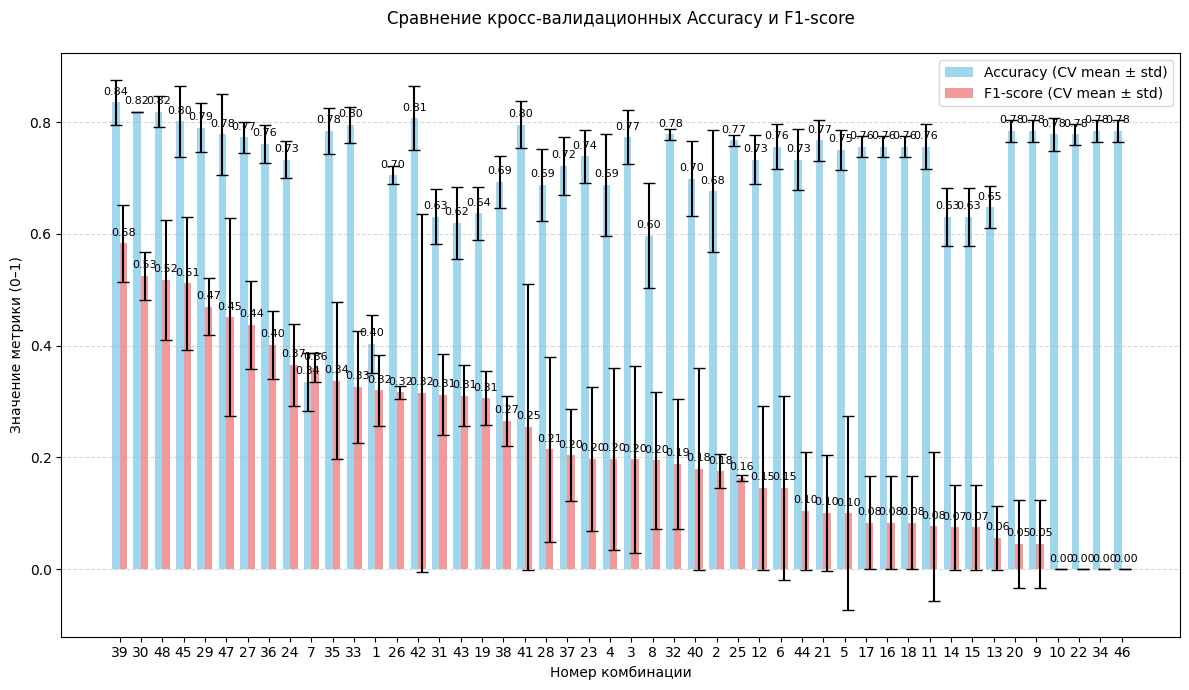

In [11]:
df_res_without_1layer = plot_results(df_res_without_1layer, 
                                     output_path='results/unchanged/hyperparameter_tuning_histograms_1layer.png')

df_res_without_1layer.to_csv('results/unchanged/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [12]:
display(df_res_without_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,39,"(100,)",relu,adam,1000,0.835227,0.040576,0.582895,0.068403
1,30,"(50,)",relu,lbfgs,1000,0.818182,0.000000,0.525000,0.043301
2,48,"(100,)",tanh,lbfgs,1000,0.818182,0.027835,0.517437,0.106789
3,45,"(100,)",tanh,adam,1000,0.801136,0.063014,0.511395,0.118377
4,29,"(50,)",relu,lbfgs,100,0.789773,0.043643,0.469444,0.051144
5,47,"(100,)",tanh,lbfgs,100,0.778409,0.072541,0.450776,0.177117
6,27,"(50,)",relu,adam,1000,0.772727,0.027835,0.437344,0.079066
7,36,"(50,)",tanh,lbfgs,1000,0.761364,0.034091,0.401456,0.060552
8,24,"(25,)",tanh,lbfgs,1000,0.732955,0.033614,0.365328,0.073606
9,7,"(10,)",tanh,adam,10,0.335227,0.051764,0.360536,0.026017


Номер выборки - 30
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.8182 ± 0.0000, F1-score = 0.5250 ± 0.0433


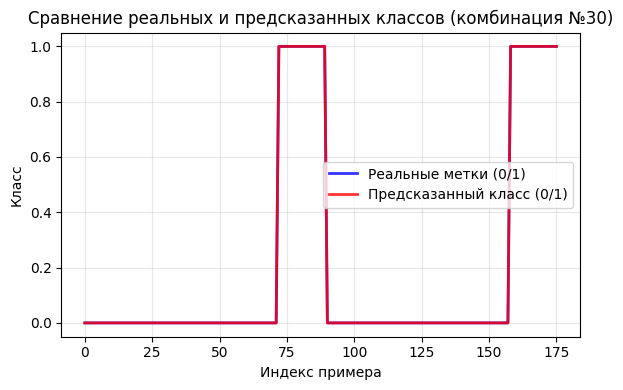

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [13]:
plot_model_by_combo_id(
    30,
    df_res_without_1layer,
    data_x,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/unchanged/layer1_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 1.2 Тестирование с двумя слоями

In [14]:
hidden_opts = [(5, 5),  
               (20, 10),
               (50, 20), 
               (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [10, 100, 1000]

In [15]:
df_res_without_2layer = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=10 → Accuracy: 0.222 (±0.019), F1-score: 0.318 (±0.005)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.301 (±0.034), F1-score: 0.335 (±0.022)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.722 (±0.079), F1-score: 0.167 (±0.102)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=10 → Accuracy: 0.795 (±0.000), F1-score: 0.045 (±0.079)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(5, 5), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(5

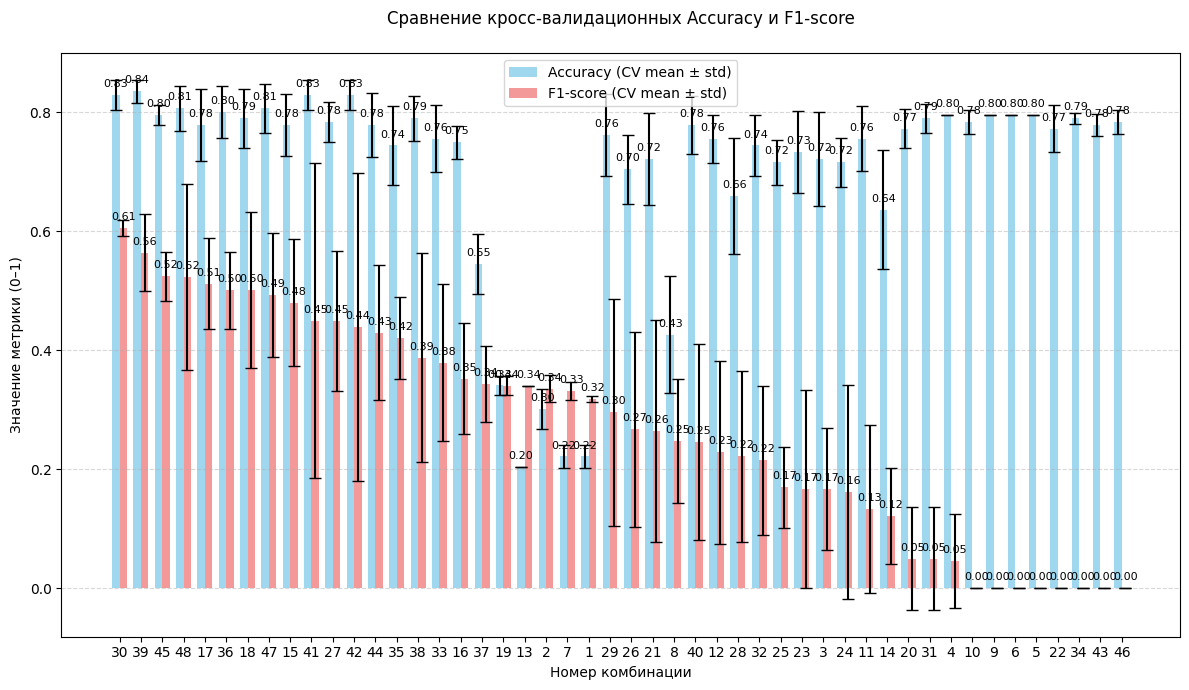

In [16]:
df_res_without_2layer = plot_results(df_res_without_2layer, 
                                     output_path='results/unchanged/hyperparameter_tuning_histograms_2layer.png')

df_res_without_2layer.to_csv('results/unchanged/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [17]:
display(df_res_without_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,30,"(50, 20)",relu,lbfgs,1000,0.829545,0.025410,0.605483,0.013405
1,39,"(100, 50)",relu,adam,1000,0.835227,0.018844,0.564145,0.064187
2,45,"(100, 50)",tanh,adam,1000,0.795455,0.016071,0.524393,0.040846
3,48,"(100, 50)",tanh,lbfgs,1000,0.806818,0.037689,0.522807,0.156642
4,17,"(20, 10)",relu,lbfgs,100,0.778409,0.060931,0.512061,0.076934
5,36,"(50, 20)",tanh,lbfgs,1000,0.801136,0.043643,0.501111,0.064972
6,18,"(20, 10)",relu,lbfgs,1000,0.789773,0.049206,0.500980,0.130995
7,47,"(100, 50)",tanh,lbfgs,100,0.806818,0.040972,0.492857,0.103974
8,15,"(20, 10)",relu,adam,1000,0.778409,0.051764,0.479864,0.106695
9,41,"(100, 50)",relu,lbfgs,100,0.829545,0.025410,0.450000,0.264050


Номер выборки - 30
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.8295 ± 0.0254, F1-score = 0.6055 ± 0.0134


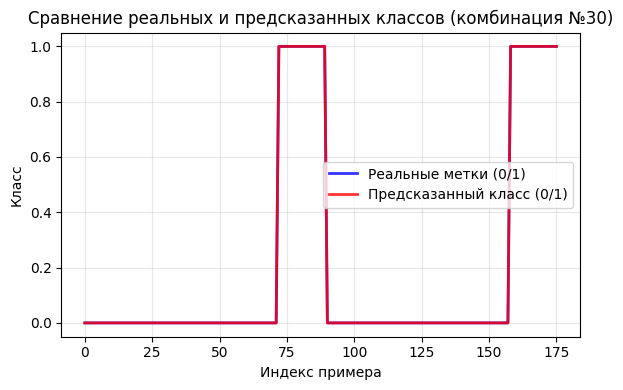

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [18]:
plot_model_by_combo_id(
    30,
    df_res_without_2layer,
    data_x,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/unchanged/layer2_prediction.png',
    dpi=600
)

#### <font color='#F5DEB3'> 1.3 Тестирование с тремя слоями

In [19]:
hidden_opts = [ (10, 10, 10),
                (30, 30, 20),
                (32, 32, 16),
                (48, 48, 32),
                (64, 64, 32)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [100, 1000]

In [20]:
df_res_without_3layer = train_models(
    data_x, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.744 (±0.034), F1-score: 0.327 (±0.084)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.761 (±0.041), F1-score: 0.291 (±0.154)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.818 (±0.028), F1-score: 0.415 (±0.146)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.824 (±0.010), F1-score: 0.439 (±0.106)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=100 → Accuracy: 0.790 (±0.010), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.778 (±0.019), F1-score: 0.000 (±0.000)
Номер набора № 7.

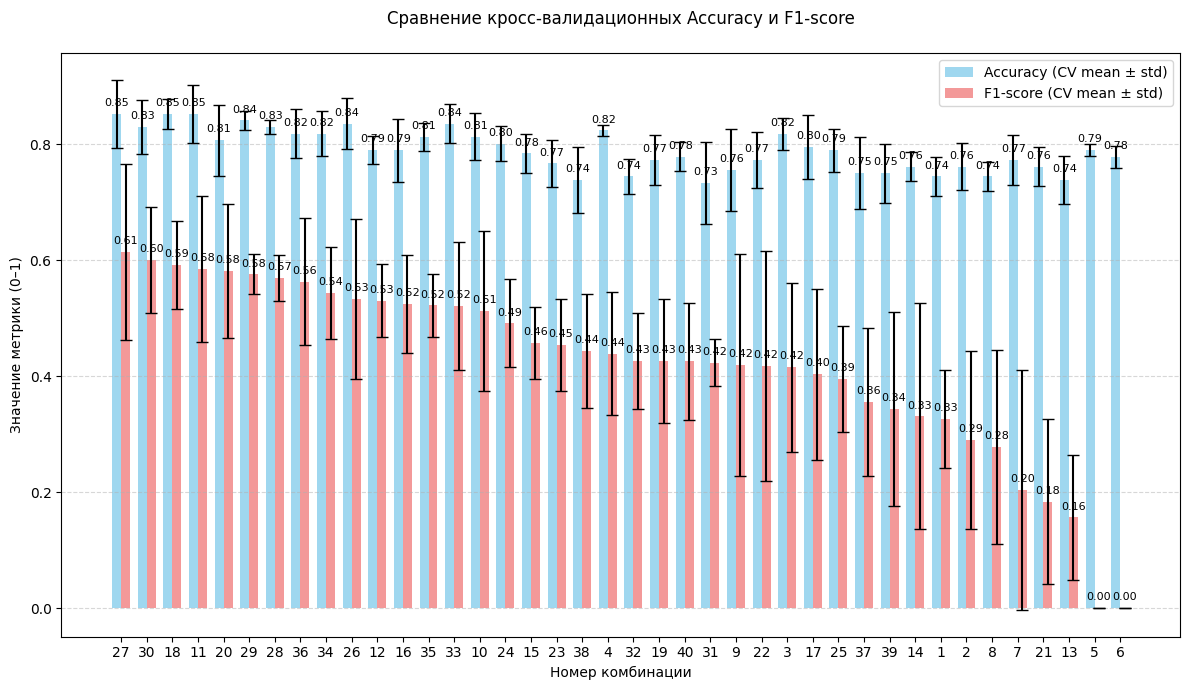

In [21]:
df_res_without_3layer = plot_results(df_res_without_3layer, 
                                     output_path='results/unchanged/hyperparameter_tuning_histograms_3layer.png')

df_res_without_3layer.to_csv('results/unchanged/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [22]:
display(df_res_without_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,27,"(48, 48, 32)",relu,lbfgs,100,0.852273,0.059047,0.614087,0.152232
1,30,"(48, 48, 32)",tanh,adam,1000,0.829545,0.046853,0.600658,0.091319
2,18,"(32, 32, 16)",relu,adam,1000,0.852273,0.025410,0.591667,0.075920
3,11,"(30, 30, 20)",relu,lbfgs,100,0.852273,0.049533,0.584821,0.126506
4,20,"(32, 32, 16)",relu,lbfgs,1000,0.806818,0.061195,0.581435,0.116146
5,29,"(48, 48, 32)",tanh,adam,100,0.840909,0.016071,0.575531,0.034599
6,28,"(48, 48, 32)",relu,lbfgs,1000,0.829545,0.011364,0.569118,0.040193
7,36,"(64, 64, 32)",relu,lbfgs,1000,0.818182,0.042519,0.563179,0.109905
8,34,"(64, 64, 32)",relu,adam,1000,0.818182,0.039365,0.543550,0.078829
9,26,"(48, 48, 32)",relu,adam,1000,0.835227,0.043643,0.533532,0.138014


Номер выборки - 18
Гиперпараметры - hidden_layer_sizes=(32, 32, 16), activation='relu', solver='adam', max_iter=1000
Кросс-валидация: Accuracy = 0.8523 ± 0.0254, F1-score = 0.5917 ± 0.0759


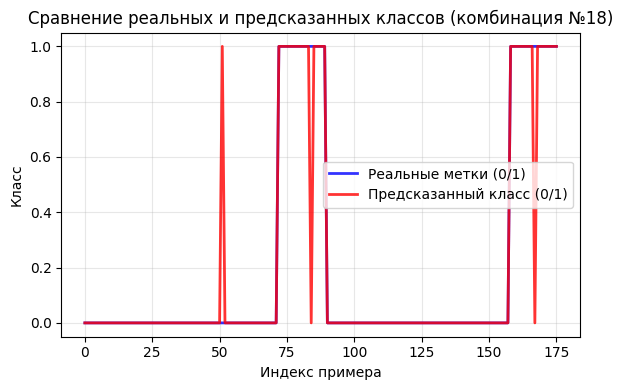

Метрики на полной выборке: Accuracy = 0.9830, F1-score = 0.9577


In [23]:
plot_model_by_combo_id(
    18,
    df_res_without_3layer,
    data_x,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/unchanged/layer3_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 1.4 Подведение итогов

* **Лучший результат 1-го слоя:**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.8182 ± 0.0000, F1-score = 0.5250 ± 0.0433

* **Лучший результат 2-го слоя:**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.8295 ± 0.0254, F1-score = 0.6055 ± 0.0134

* **Лучший результат 3-го слоя:**
Гиперпараметры - hidden_layer_sizes=(32, 32, 16), activation='relu', solver='adam', max_iter=1000
Кросс-валидация: Accuracy = 0.8523 ± 0.0254, F1-score = 0.5917 ± 0.0759

Все 3 набора гиперпараметров практически 100% предсказали обучающую выборку. Стоит отметить, что у однослойной сети малая устойчивость по F1-scope, что критично.       
**Лучший результат показала 2-слойная нейронная сеть**.     
**В целом, результаты предварительного анализа примерно совпали с результатами.** 

### <font color='#F5DEB3'>Задание №2

5. Провести  эксперимент  по  п.3  с  сортированными  данными.  Для  этого,  можно  скопировать 
предыдущий  код  в  новые  ячейки  блокнота  (ниже)  и  поменять  загрузку  датасета  в  функции 
read_excel на ‘Data Set_Train (Sort).xlsx’. 
 
6. Зафиксировать лучший полученный результат по п.5 –  выставить в блокноте результат лучшего 
найденного результата обучения  (график и значения критериев понадобятся для отчёта).

In [ ]:
def create_pattern_sequence(df, target_col, pattern=(4, 1), random_state=42):
    rng = np.random.default_rng(random_state)
    
    idx0 = df[df[target_col] == 0].index.values
    idx1 = df[df[target_col] == 1].index.values
    rng.shuffle(idx0)
    rng.shuffle(idx1)
    
    n_blocks = min(len(idx0) // pattern[0], len(idx1) // pattern[1])
    
    blocks = []
    for i in range(n_blocks):
        block = np.concatenate([
            idx0[i*pattern[0] : (i+1)*pattern[0]],
            idx1[i*pattern[1] : (i+1)*pattern[1]]
        ])
        blocks.append(block)
    
    leftover0 = idx0[n_blocks*pattern[0]:]
    leftover1 = idx1[n_blocks*pattern[1]:]
    leftover = np.concatenate([leftover0, leftover1])
    if len(leftover) > 0:
        blocks.append(leftover)
    
    new_order = np.concatenate(blocks)
    return df.loc[new_order].reset_index(drop=True)

In [25]:
target_col = config['data']['target_column']
data_y = V13[target_col].values

V13_sorted = create_pattern_sequence(V13, target_col, pattern=(4, 1))
data_x_sorted = V13_sorted.drop(target_col, axis=1).values
data_y_sorted = V13_sorted[target_col].values

V13_sorted.to_excel('data/processed/Data_Set_sorted.xlsx', index=False)

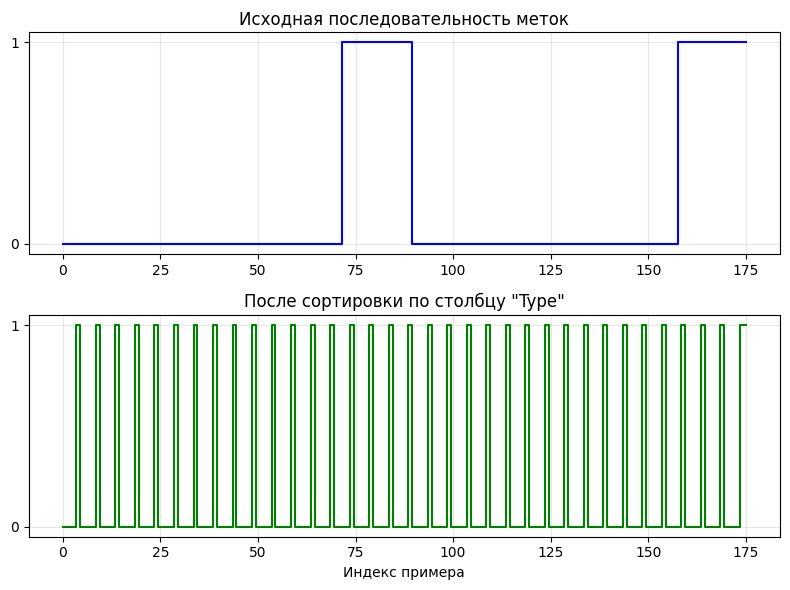

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].step(np.arange(len(data_y)), data_y, where='mid', color='blue')
axes[0].set_title('Исходная последовательность меток')
axes[0].set_yticks([0, 1])
axes[0].grid(True, alpha=0.3)

axes[1].step(np.arange(len(data_y_sorted)), data_y_sorted, where='mid', color='green')
axes[1].set_title('После сортировки по столбцу "Type"')
axes[1].set_xlabel('Индекс примера')
axes[1].set_yticks([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### <font color='#F5DEB3'> 2.1 Тестирование с одним слоем

In [27]:
hidden_opts = [(25,), (50,), (100,), (200,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [100, 1000, 2000]


In [28]:
df_res_sorted_1layer = train_models(
    data_x_sorted, data_y_sorted,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(25,), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.625 (±0.086), F1-score: 0.058 (±0.060)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(25,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.625 (±0.086), F1-score: 0.058 (±0.060)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(25,), activation=relu, solver=adam, max_iter=2000 → Accuracy: 0.625 (±0.086), F1-score: 0.058 (±0.060)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(25,), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.761 (±0.025), F1-score: 0.080 (±0.080)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(25,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.761 (±0.025), F1-score: 0.080 (±0.080)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(25,), activation=relu, solver=lbfgs, max_iter=2000 → Accuracy: 0.761 (±0.025), F1-score: 0.080 (±0.080)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(25,

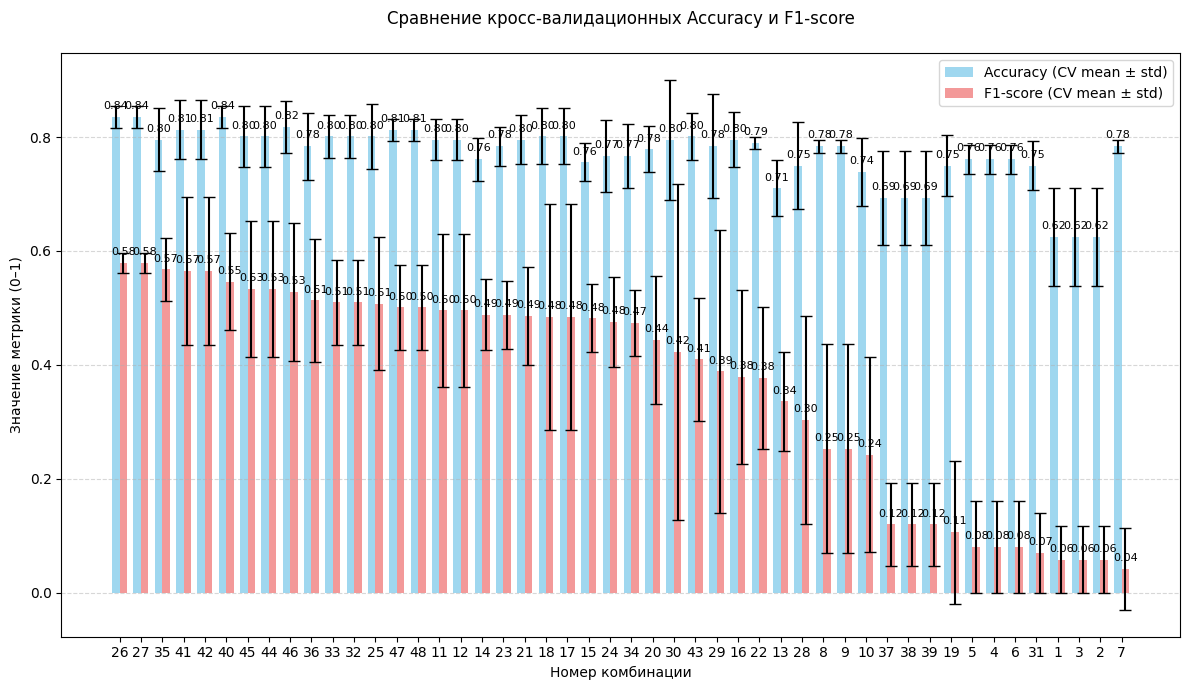

In [29]:
df_res_sorted_1layer = plot_results(df_res_sorted_1layer, 
                                     output_path='results/sorted/hyperparameter_tuning_histograms_1layer.png')

df_res_sorted_1layer.to_csv('results/sorted/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [30]:
display(df_res_sorted_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,26,"(100,)",relu,adam,1000,0.835227,0.018844,0.578805,0.016831
1,27,"(100,)",relu,adam,2000,0.835227,0.018844,0.578805,0.016831
2,35,"(100,)",tanh,lbfgs,1000,0.795455,0.055670,0.567811,0.055243
3,41,"(200,)",relu,lbfgs,1000,0.812500,0.051764,0.565319,0.129547
4,42,"(200,)",relu,lbfgs,2000,0.812500,0.051764,0.565319,0.129547
5,40,"(200,)",relu,lbfgs,100,0.835227,0.018844,0.546288,0.085834
6,45,"(200,)",tanh,adam,2000,0.801136,0.054201,0.533170,0.118818
7,44,"(200,)",tanh,adam,1000,0.801136,0.054201,0.533170,0.118818
8,46,"(200,)",tanh,lbfgs,100,0.818182,0.045455,0.527778,0.121478
9,36,"(100,)",tanh,lbfgs,2000,0.784091,0.059047,0.513189,0.107737


Номер выборки - 26
Гиперпараметры - hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000
Кросс-валидация: Accuracy = 0.8352 ± 0.0188, F1-score = 0.5788 ± 0.0168


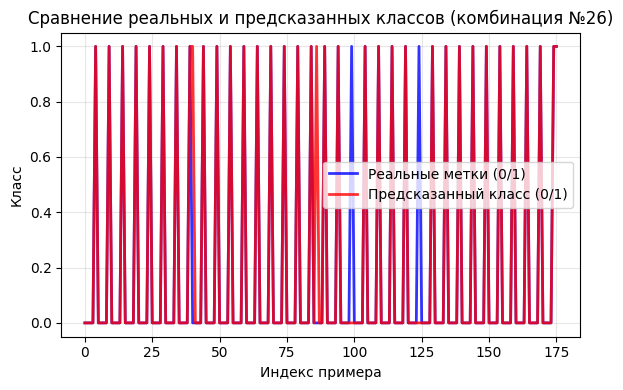

Метрики на полной выборке: Accuracy = 0.9773, F1-score = 0.9444


In [31]:
plot_model_by_combo_id(
    26,
    df_res_sorted_1layer,
    data_x_sorted,
    data_y_sorted,
    config['base']['random_state'],
    n_show=len(data_x_sorted),
    output_path='results/sorted/layer1_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 2.2 Тестирование с двумя слоями

In [32]:
hidden_opts = [(20, 10), 
               (20, 20), 
               (40, 40),
               (50, 20), 
               (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [100, 1000]

In [33]:
df_res_sorted_2layer = train_models(
    data_x_sorted, data_y_sorted,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.676 (±0.059), F1-score: 0.108 (±0.075)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.790 (±0.034), F1-score: 0.377 (±0.233)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.818 (±0.028), F1-score: 0.538 (±0.098)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.852 (±0.041), F1-score: 0.640 (±0.090)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=100 → Accuracy: 0.767 (±0.025), F1-score: 0.042 (±0.072)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.739 (±0.041), F1-score: 0.268 (±0.168)
Номер набора № 7. Гиперпараметры: hidden_

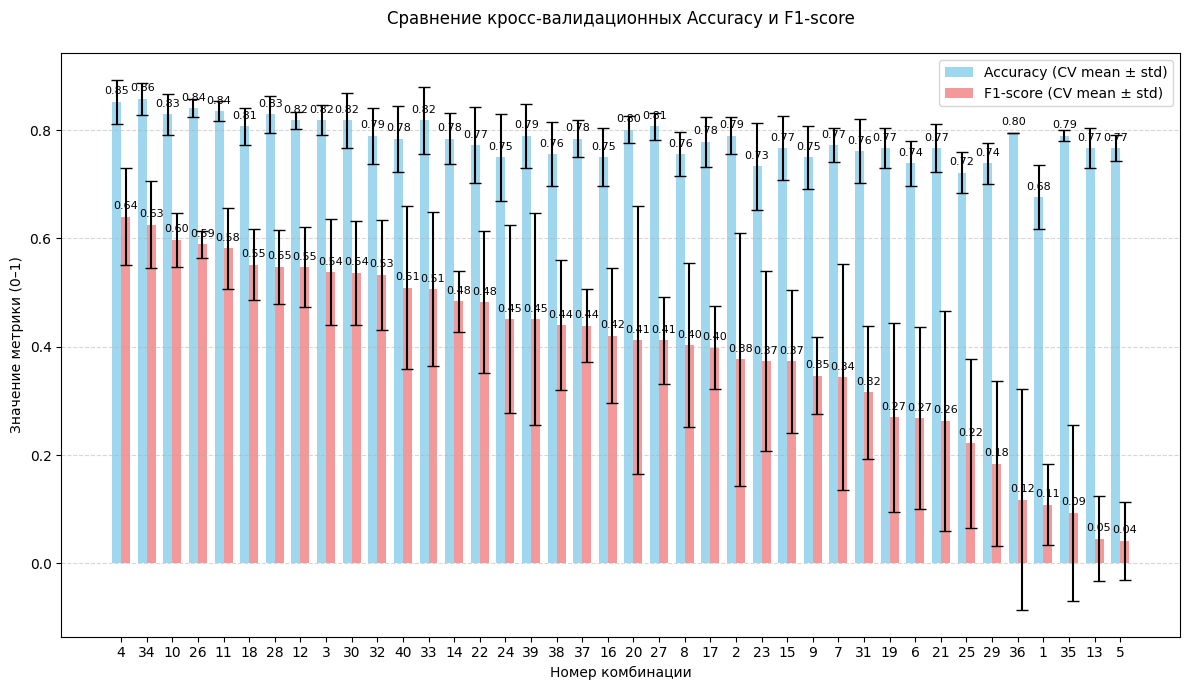

In [34]:
df_res_sorted_2layer = plot_results(df_res_sorted_2layer, 
                                     output_path='results/sorted/hyperparameter_tuning_histograms_2layer.png')

df_res_sorted_2layer.to_csv('results/sorted/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [35]:
display(df_res_sorted_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,4,"(20, 10)",relu,lbfgs,1000,0.852273,0.040972,0.640168,0.089725
1,34,"(100, 50)",relu,adam,1000,0.857955,0.029524,0.625787,0.079719
2,10,"(20, 20)",relu,adam,1000,0.829545,0.037689,0.597478,0.050156
3,26,"(50, 20)",relu,adam,1000,0.840909,0.016071,0.589257,0.024574
4,11,"(20, 20)",relu,lbfgs,100,0.835227,0.018844,0.582051,0.074712
5,18,"(40, 40)",relu,adam,1000,0.806818,0.034091,0.551942,0.065360
6,28,"(50, 20)",relu,lbfgs,1000,0.829545,0.034091,0.547753,0.067983
7,12,"(20, 20)",relu,lbfgs,1000,0.818182,0.016071,0.546784,0.073907
8,3,"(20, 10)",relu,lbfgs,100,0.818182,0.027835,0.537592,0.097669
9,30,"(50, 20)",tanh,adam,1000,0.818182,0.050820,0.536636,0.096556


Номер выборки - 26
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='adam', max_iter=1000
Кросс-валидация: Accuracy = 0.8409 ± 0.0161, F1-score = 0.5893 ± 0.0246


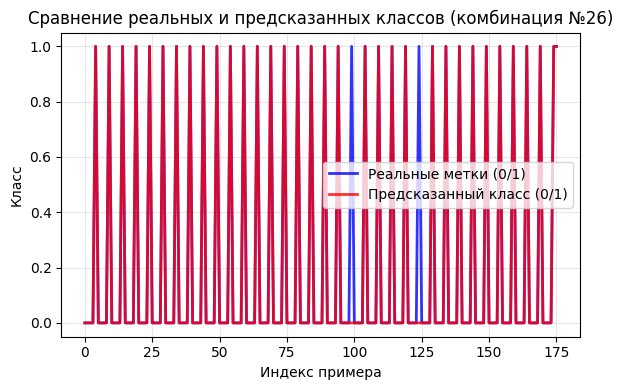

Метрики на полной выборке: Accuracy = 0.9886, F1-score = 0.9714


In [36]:
plot_model_by_combo_id(
    26,
    df_res_sorted_2layer,
    data_x_sorted,
    data_y_sorted,
    config['base']['random_state'],
    n_show=len(data_x_sorted),
    output_path='results/sorted/layer2_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 2.3 Тестирование с тремя слоями

In [37]:
hidden_opts = [ (16, 16, 16),
                (30, 30, 20),
                (32, 32, 16),
                (48, 48, 32),
                (64, 64, 32)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [100, 1000]

In [38]:
df_res_sorted_3layer = train_models(
    data_x_sorted, data_y_sorted,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.761 (±0.061), F1-score: 0.323 (±0.157)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.830 (±0.065), F1-score: 0.580 (±0.144)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.835 (±0.052), F1-score: 0.582 (±0.125)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.835 (±0.052), F1-score: 0.582 (±0.125)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=tanh, solver=adam, max_iter=100 → Accuracy: 0.790 (±0.010), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.761 (±0.011), F1-score: 0.317 (±0.207)
Номер набора № 7.

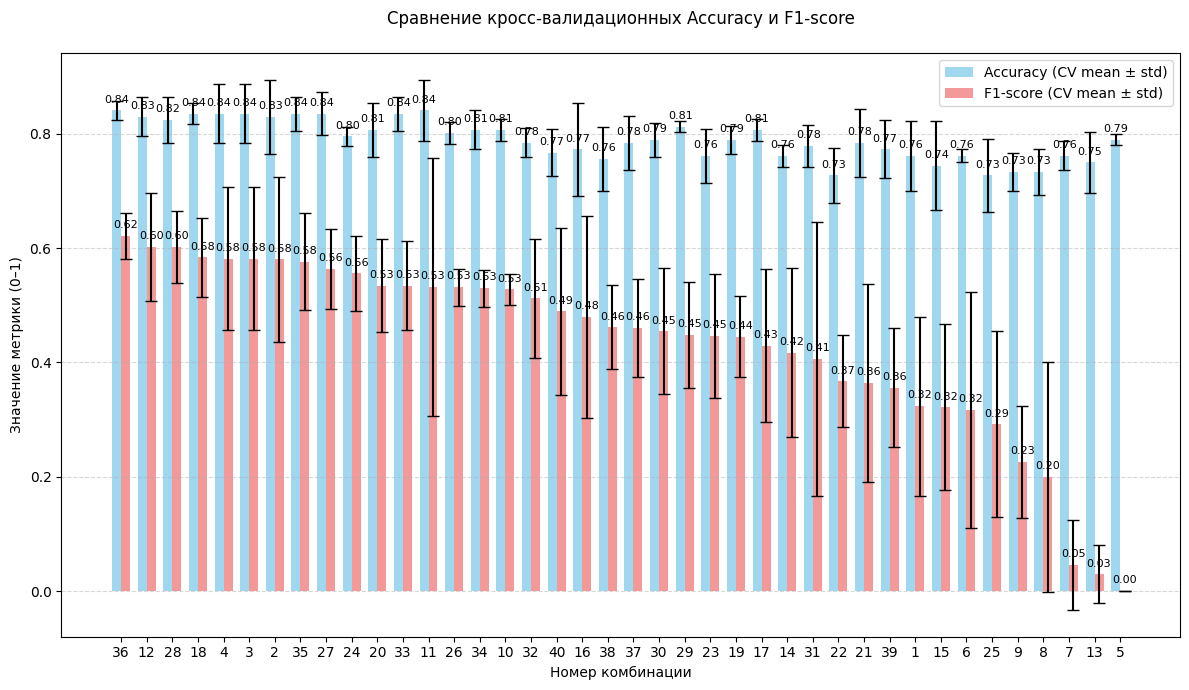

In [39]:
df_res_sorted_3layer = plot_results(df_res_sorted_3layer, 
                                     output_path='results/sorted/hyperparameter_tuning_histograms_3layer.png')

df_res_sorted_3layer.to_csv('results/sorted/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [40]:
display(df_res_sorted_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,36,"(64, 64, 32)",relu,lbfgs,1000,0.840909,0.016071,0.621345,0.040595
1,12,"(30, 30, 20)",relu,lbfgs,1000,0.829545,0.034091,0.601858,0.094153
2,28,"(48, 48, 32)",relu,lbfgs,1000,0.823864,0.040576,0.601723,0.063541
3,18,"(32, 32, 16)",relu,adam,1000,0.835227,0.018844,0.584091,0.069280
4,4,"(16, 16, 16)",relu,lbfgs,1000,0.835227,0.051764,0.581699,0.124527
5,3,"(16, 16, 16)",relu,lbfgs,100,0.835227,0.051764,0.581699,0.124527
6,2,"(16, 16, 16)",relu,adam,1000,0.829545,0.065279,0.580392,0.144088
7,35,"(64, 64, 32)",relu,lbfgs,100,0.835227,0.029524,0.576471,0.085142
8,27,"(48, 48, 32)",relu,lbfgs,100,0.835227,0.037258,0.563725,0.069497
9,24,"(32, 32, 16)",tanh,lbfgs,1000,0.795455,0.016071,0.556142,0.065946


Номер выборки - 36
Гиперпараметры - hidden_layer_sizes=(64, 64, 32), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.8409 ± 0.0161, F1-score = 0.6213 ± 0.0406


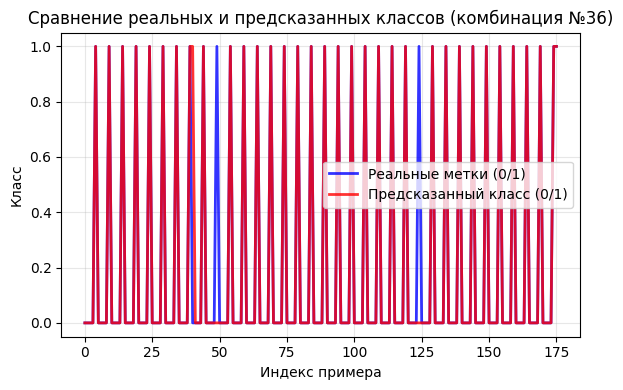

Метрики на полной выборке: Accuracy = 0.9830, F1-score = 0.9577


In [41]:
plot_model_by_combo_id(
    36,
    df_res_sorted_3layer,
    data_x_sorted,
    data_y_sorted,
    config['base']['random_state'],
    n_show=len(data_x),
    output_path='results/sorted/layer3_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 2.4 Подведение итогов

* **Лучший результат 1-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 1-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000.    
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415.

* **Лучший результат 2-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.
Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.

* **Лучший результат 2-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000.     
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465.

* **Лучший результат 3-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

* **Лучший результат 3-го слоя (Sorted):**
*Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000.*   
*Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430.*

**Лучший результат: 3 слоя с сортировкой датасета**.

### <font color='#F5DEB3'>Задание №3

7. Поскольку все датчики имеют различные диапазоны измерений, то логично их привести к одному 
диапазону (например, [0,1]) для того, чтобы их вклад в функцию нейрона был одинаковым. Для 
нормализации  данных  можно  воспользоваться  функцией  MinMaxScaler  библиотеки  Sklearn 
(https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).
 
8. Провести эксперимент по п.3 с нормализованными данными. При этом, в качестве выборки данных, 
которая загружается в переменную Data из Excel, необходимо выбрать ту (с сортировкой или без 
сортировки),  на  которой  в  предыдущих  экспериментах  результат  получился  лучше  по  кросс-
валидации и критерию F1. 
 
9.  Зафиксировать лучший полученный результат по п.8 –  выставить в блокноте результат лучшего 
найденного результата обучения (график и значения критериев понадобятся для отчёта).

In [42]:
scaler = MinMaxScaler()

data_x_scaled = scaler.fit_transform(data_x)

#### <font color='#F5DEB3'> 3.1 Тестирование с одним слоем

In [43]:
hidden_opts = [(50,), (100,), (150,), (200,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]

In [44]:
df_res_scaled_1layer = train_models(
    data_x_scaled, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.773 (±0.053), F1-score: 0.095 (±0.096)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.812 (±0.059), F1-score: 0.494 (±0.157)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.818 (±0.028), F1-score: 0.549 (±0.102)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.818 (±0.028), F1-score: 0.549 (±0.102)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.767 (±0.049), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.767 (±0.037), F1-score: 0.000 (±0.000)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(50,),

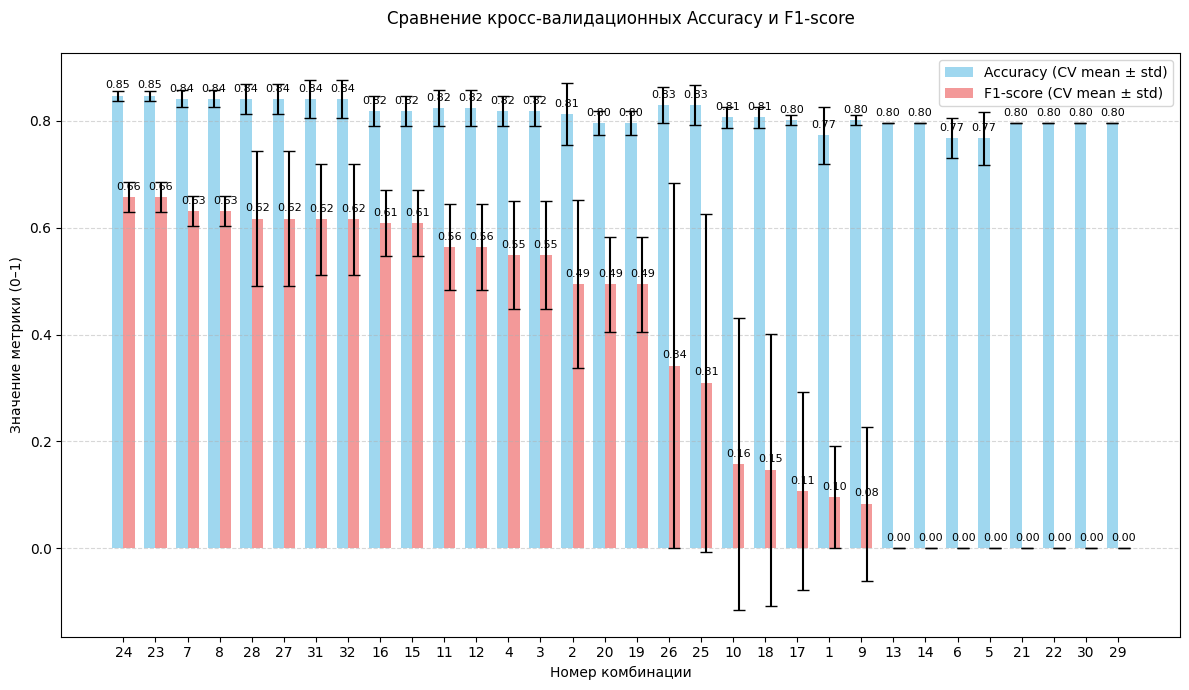

In [45]:
df_res_scaled_1layer = plot_results(df_res_scaled_1layer, 
                                     output_path='results/scaled/hyperparameter_tuning_histograms_1layer.png')

df_res_scaled_1layer.to_csv('results/scaled/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [46]:
display(df_res_scaled_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,24,"(150,)",tanh,lbfgs,1000,0.846591,0.009841,0.657456,0.028434
1,23,"(150,)",tanh,lbfgs,500,0.846591,0.009841,0.657456,0.028434
2,7,"(50,)",tanh,lbfgs,500,0.840909,0.016071,0.630711,0.027972
3,8,"(50,)",tanh,lbfgs,1000,0.840909,0.016071,0.630711,0.027972
4,28,"(200,)",relu,lbfgs,1000,0.840909,0.027835,0.616667,0.125831
5,27,"(200,)",relu,lbfgs,500,0.840909,0.027835,0.616667,0.125831
6,31,"(200,)",tanh,lbfgs,500,0.840909,0.035935,0.615789,0.103872
7,32,"(200,)",tanh,lbfgs,1000,0.840909,0.035935,0.615789,0.103872
8,16,"(100,)",tanh,lbfgs,1000,0.818182,0.027835,0.608753,0.061641
9,15,"(100,)",tanh,lbfgs,500,0.818182,0.027835,0.608753,0.061641


Номер выборки - 7
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=500
Кросс-валидация: Accuracy = 0.8409 ± 0.0161, F1-score = 0.6307 ± 0.0280


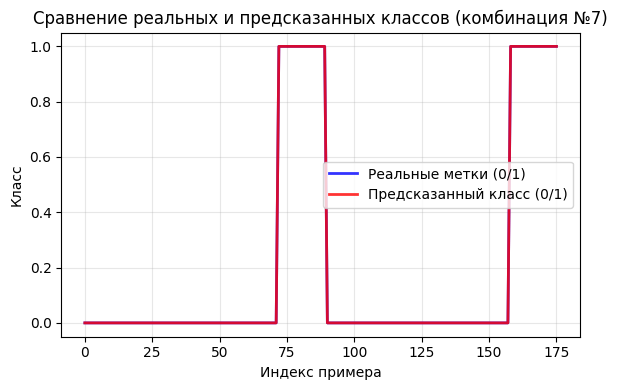

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [47]:
plot_model_by_combo_id( 
    7,
    df_res_scaled_1layer,
    data_x_scaled,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x_scaled),
    output_path='results/scaled/layer1_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 3.2 Тестирование с двумя слоями

In [48]:
hidden_opts = [(20, 10), 
               (20, 20), 
               (40, 30),
               (50, 20), 
               (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]

In [49]:
df_res_scaled_2layer = train_models(
    data_x_scaled, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.812 (±0.049), F1-score: 0.462 (±0.189)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.756 (±0.079), F1-score: 0.468 (±0.177)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.784 (±0.057), F1-score: 0.490 (±0.166)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.795 (±0.000), F1-score: 0.000 (±0.000)
Номер набора № 7. Гиперпараметры: hidden_

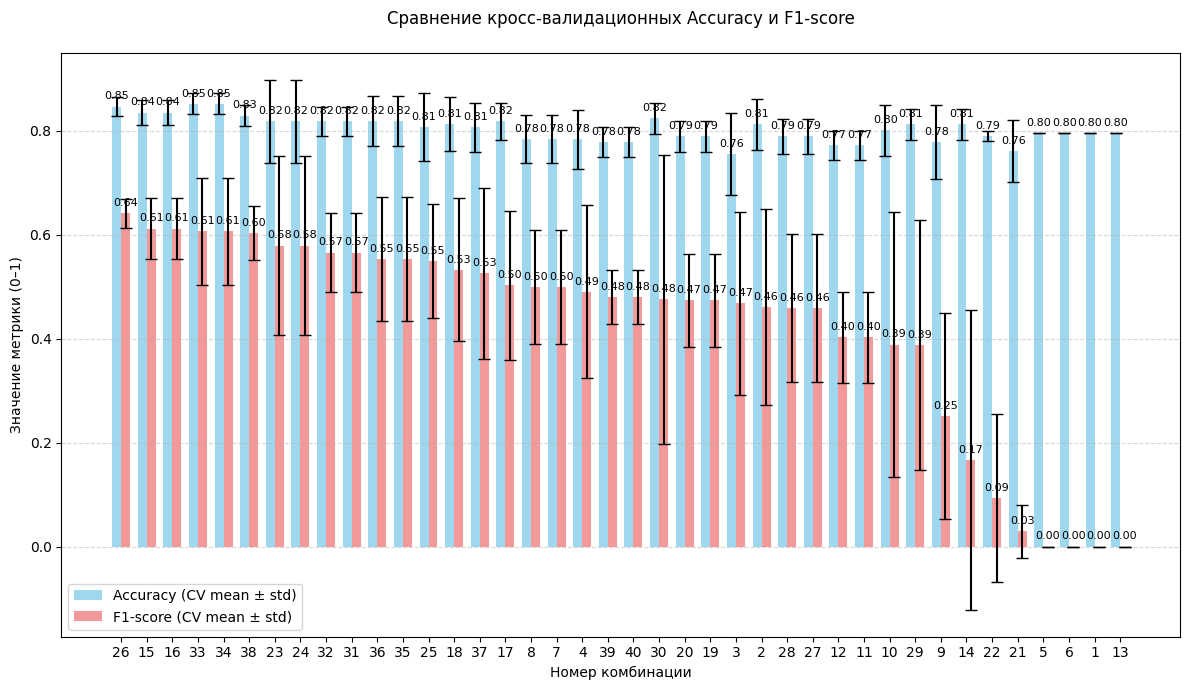

In [50]:
df_res_scaled_2layer = plot_results(df_res_scaled_2layer, 
                                     output_path='results/scaled/hyperparameter_tuning_histograms_2layer.png')

df_res_scaled_2layer.to_csv('results/scaled/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [51]:
display(df_res_scaled_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,26,"(50, 20)",relu,adam,1000,0.846591,0.018844,0.641228,0.027781
1,15,"(20, 20)",tanh,lbfgs,500,0.835227,0.024766,0.611971,0.058914
2,16,"(20, 20)",tanh,lbfgs,1000,0.835227,0.024766,0.611971,0.058914
3,33,"(100, 50)",relu,adam,500,0.852273,0.019682,0.607143,0.103098
4,34,"(100, 50)",relu,adam,1000,0.852273,0.019682,0.607143,0.103098
5,38,"(100, 50)",tanh,adam,1000,0.829545,0.019682,0.603199,0.052365
6,23,"(40, 30)",tanh,lbfgs,500,0.818182,0.080353,0.579202,0.172530
7,24,"(40, 30)",tanh,lbfgs,1000,0.818182,0.080353,0.579202,0.172530
8,32,"(50, 20)",tanh,lbfgs,1000,0.818182,0.027835,0.565789,0.076625
9,31,"(50, 20)",tanh,lbfgs,500,0.818182,0.027835,0.565789,0.076625


Номер выборки - 26
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='adam', max_iter=1000
Кросс-валидация: Accuracy = 0.8466 ± 0.0188, F1-score = 0.6412 ± 0.0278


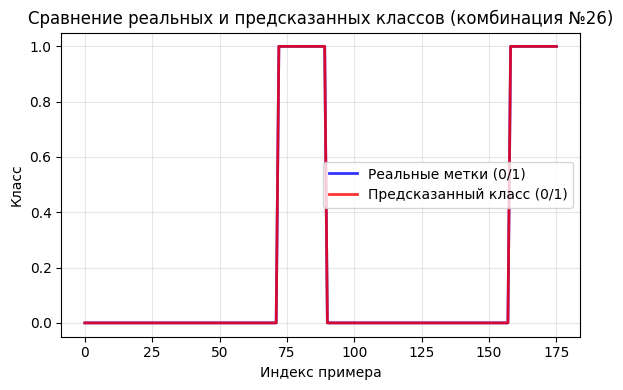

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [52]:
plot_model_by_combo_id(
    26,
    df_res_scaled_2layer,
    data_x_scaled,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x_scaled),
    output_path='results/scaled/layer2_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 3.3 Тестирование с тремя слоями

In [53]:
hidden_opts = [ (16, 16, 16),
                (30, 30, 20),
                (32, 32, 16),
                (48, 48, 32),
                (64, 64, 32)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]

In [54]:
df_res_scaled_3layer = train_models(
    data_x_scaled, data_y,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.790 (±0.054), F1-score: 0.424 (±0.168)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.812 (±0.019), F1-score: 0.557 (±0.058)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.773 (±0.074), F1-score: 0.514 (±0.148)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.767 (±0.067), F1-score: 0.506 (±0.138)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.835 (±0.010), F1-score: 0.613 (±0.033)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(16, 16, 16), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.835 (±0.010), F1-score: 0.613 (±0.033)
Номер набора № 7.

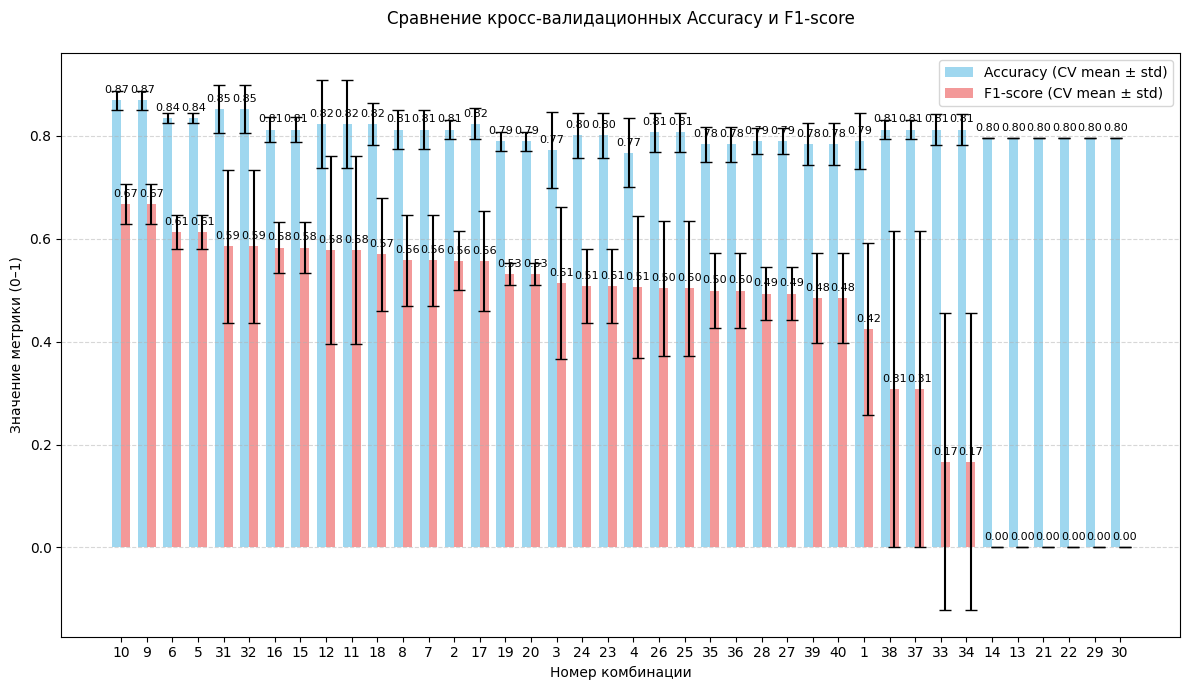

In [55]:
df_res_scaled_3layer = plot_results(df_res_scaled_3layer, 
                                     output_path='results/scaled/hyperparameter_tuning_histograms_3layer.png')

df_res_scaled_3layer.to_csv('results/scaled/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [56]:
display(df_res_scaled_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,10,"(30, 30, 20)",relu,adam,1000,0.869318,0.018844,0.667086,0.038866
1,9,"(30, 30, 20)",relu,adam,500,0.869318,0.018844,0.667086,0.038866
2,6,"(16, 16, 16)",tanh,adam,1000,0.835227,0.009841,0.612573,0.032919
3,5,"(16, 16, 16)",tanh,adam,500,0.835227,0.009841,0.612573,0.032919
4,31,"(48, 48, 32)",tanh,lbfgs,500,0.852273,0.046853,0.585084,0.148830
5,32,"(48, 48, 32)",tanh,lbfgs,1000,0.852273,0.046853,0.585084,0.148830
6,16,"(30, 30, 20)",tanh,lbfgs,1000,0.812500,0.024766,0.582895,0.049565
7,15,"(30, 30, 20)",tanh,lbfgs,500,0.812500,0.024766,0.582895,0.049565
8,12,"(30, 30, 20)",relu,lbfgs,1000,0.823864,0.085605,0.577778,0.183081
9,11,"(30, 30, 20)",relu,lbfgs,500,0.823864,0.085605,0.577778,0.183081


Номер выборки - 10
Гиперпараметры - hidden_layer_sizes=(30, 30, 20), activation='relu', solver='adam', max_iter=1000
Кросс-валидация: Accuracy = 0.8693 ± 0.0188, F1-score = 0.6671 ± 0.0389


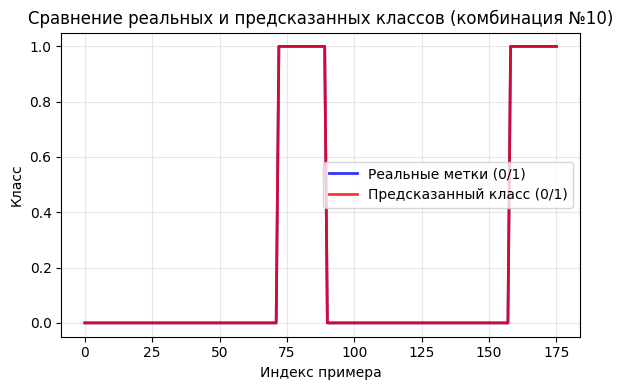

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [57]:
plot_model_by_combo_id(
    10,
    df_res_scaled_3layer,
    data_x_scaled,
    data_y,
    config['base']['random_state'],
    n_show=len(data_x_scaled),
    output_path='results/scaled/layer3_prediction.png',
    dpi=300
)

#### <font color='#F5DEB3'> 3.4 Подведение итогов

* **Лучший результат 1-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 1-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000.    
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415.

* **Лучший результат 1-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(100,), activation='tanh', solver='lbfgs', max_iter=1000.   
Accuracy = 0.8409 ± 0.0321, F1-score = 0.6358 ± 0.0882.

* **Лучший результат 2-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.
Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.

* **Лучший результат 2-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000.     
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465.

* **Лучший результат 2-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=5000.     
Accuracy = 0.8011 ± 0.0098, F1-score = 0.5504 ± 0.1001.

* **Лучший результат 3-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

* **Лучший результат 3-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000.   
Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430.

* **Лучший результат 3-го слоя (MinMaxScaled):**
*Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='tanh', solver='lbfgs', max_iter=5000.*       
*Accuracy = 0.8466 ± 0.0295, F1-score = 0.6399 ± 0.0670.*

**Лучший результат: 3 слоя с нормализацией датасета**.

### <font color='#F5DEB3'>Задание №4

10. Провести балансировку классов через SMOTE и ADASYN
 
11. Провести  эксперимент  по  п.3  с  балансированными  данными  (необходимо  применить  оба 
алгоритма балансировки, в примере выше приведено использование алгоритма SMOTE, алгоритм 
ADASYN вызывается и используется абсолютно аналогично, необходимо лишь в импорте указать 
ADASYN вместо SMOTE, а также в строке с инициализацией алгоритма). При этом, в качестве 
выборки данных, которая загружается в переменную Data из Excel, необходимо выбрать ту (с 
нормализацией  или  без  нормализации),  на  которой  в  предыдущих  экспериментах  результат 
получился лучше всего по совокупности кросс-валидации и критерию F1. 
 
12.  Зафиксировать лучший полученный результат по п.8 – выставить в блокноте результат лучшего 
найденного результата обучения  (график и значения критериев понадобятся для отчёта).  
Добавить в блокноте новое поле ниже, выбрать вместо «Code», режим «Markdown» и написать 
заголовок:

#### <font color='#F5DEB3'> 4.1 Балансировка класса с SMOTE

In [58]:
smote = SMOTE(random_state=42)

X_smote, Y_smote = smote.fit_resample(data_x_scaled, data_y)


##### <font color='#F5DEB3'> 4.1.1 Тестирование с одним слоем

In [59]:
hidden_opts = [(50,), (100,), (150,), (200,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]

In [60]:
df_res_smote_1layer = train_models(
    X_smote, Y_smote,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.846 (±0.031), F1-score: 0.861 (±0.028)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.868 (±0.027), F1-score: 0.881 (±0.022)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.925 (±0.016), F1-score: 0.930 (±0.013)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.925 (±0.016), F1-score: 0.930 (±0.013)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.550 (±0.016), F1-score: 0.682 (±0.010)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.550 (±0.016), F1-score: 0.682 (±0.010)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(50,),

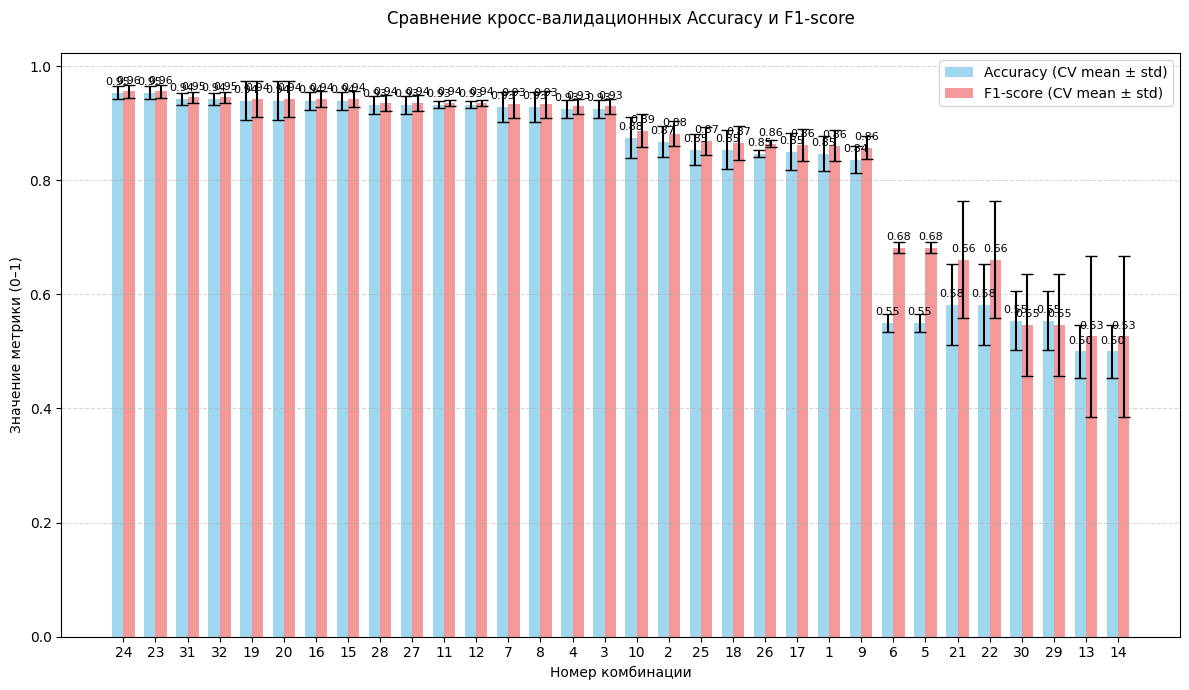

In [61]:
df_res_smote_1layer = plot_results(df_res_smote_1layer, 
                                     output_path='results/smote/hyperparameter_tuning_histograms_1layer.png')

df_res_smote_1layer.to_csv('results/smote/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [62]:
display(df_res_smote_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,24,"(150,)",tanh,lbfgs,1000,0.953571,0.011845,0.955755,0.010880
1,23,"(150,)",tanh,lbfgs,500,0.953571,0.011845,0.955755,0.010880
2,31,"(200,)",tanh,lbfgs,500,0.942857,0.010102,0.945260,0.009147
3,32,"(200,)",tanh,lbfgs,1000,0.942857,0.010102,0.945260,0.009147
4,19,"(150,)",relu,lbfgs,500,0.939286,0.034069,0.942601,0.031599
5,20,"(150,)",relu,lbfgs,1000,0.939286,0.034069,0.942601,0.031599
6,16,"(100,)",tanh,lbfgs,1000,0.939286,0.015567,0.942587,0.013645
7,15,"(100,)",tanh,lbfgs,500,0.939286,0.015567,0.942587,0.013645
8,28,"(200,)",relu,lbfgs,1000,0.932143,0.015567,0.935717,0.014107
9,27,"(200,)",relu,lbfgs,500,0.932143,0.015567,0.935717,0.014107


Номер выборки - 24
Гиперпараметры - hidden_layer_sizes=(150,), activation='tanh', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.9536 ± 0.0118, F1-score = 0.9558 ± 0.0109


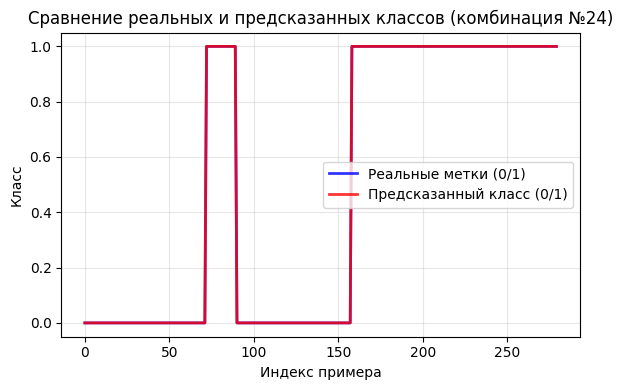

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [63]:
plot_model_by_combo_id(
    24,
    df_res_smote_1layer,
    X_smote,
    Y_smote,
    config['base']['random_state'],
    len(X_smote)
)

##### <font color='#F5DEB3'> 4.1.2 Тестирование с двумя слоями

In [64]:
hidden_opts = [(20, 10), (20, 20), (40, 30), (50, 20), (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]

In [65]:
df_res_smote_2layer = train_models(
    X_smote, Y_smote,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.836 (±0.012), F1-score: 0.851 (±0.014)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.868 (±0.033), F1-score: 0.876 (±0.031)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.914 (±0.023), F1-score: 0.920 (±0.020)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.914 (±0.023), F1-score: 0.920 (±0.020)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.511 (±0.050), F1-score: 0.641 (±0.045)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.511 (±0.050), F1-score: 0.641 (±0.045)
Номер набора № 7. Гиперпараметры: hidden_

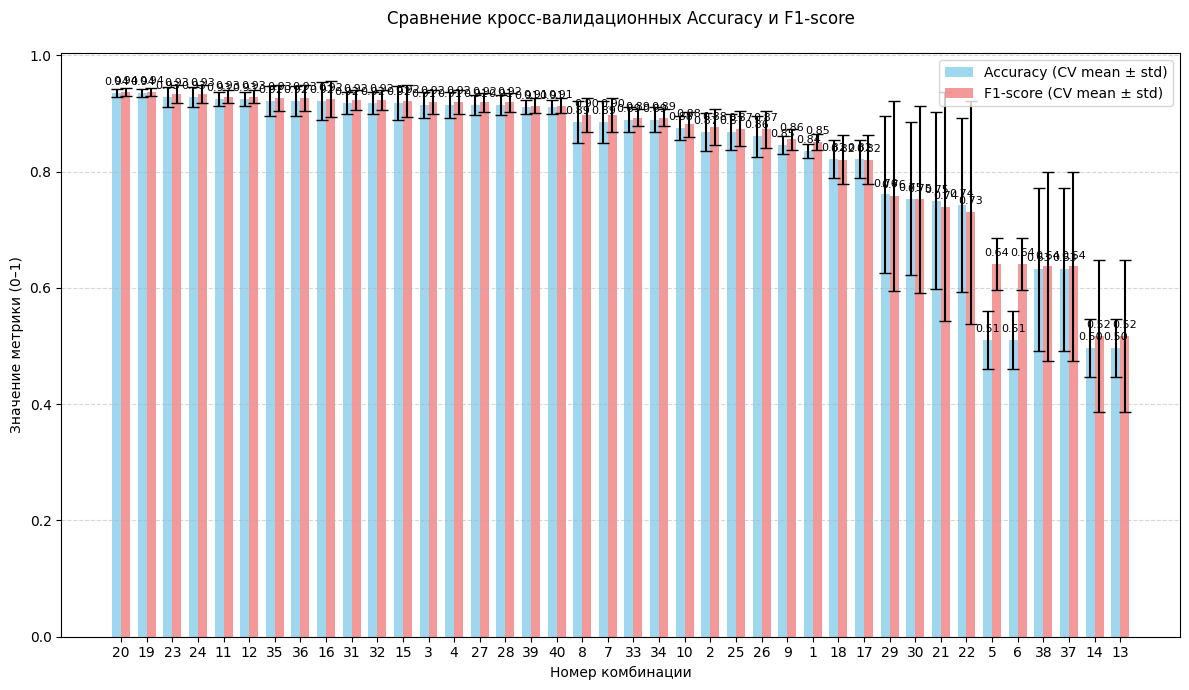

In [66]:
df_res_smote_2layer = plot_results(df_res_smote_2layer, 
                                     output_path='results/smote/hyperparameter_tuning_histograms_2layer.png')

df_res_smote_2layer.to_csv('results/smote/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [67]:
display(df_res_smote_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,20,"(40, 30)",relu,lbfgs,1000,0.935714,0.007143,0.936990,0.007492
1,19,"(40, 30)",relu,lbfgs,500,0.935714,0.007143,0.936990,0.007492
2,23,"(40, 30)",tanh,lbfgs,500,0.928571,0.017496,0.933122,0.015075
3,24,"(40, 30)",tanh,lbfgs,1000,0.928571,0.017496,0.933122,0.015075
4,11,"(20, 20)",relu,lbfgs,500,0.925000,0.011845,0.928874,0.010869
5,12,"(20, 20)",relu,lbfgs,1000,0.925000,0.011845,0.928874,0.010869
6,35,"(100, 50)",relu,lbfgs,500,0.921429,0.025754,0.926128,0.022450
7,36,"(100, 50)",relu,lbfgs,1000,0.921429,0.025754,0.926128,0.022450
8,16,"(20, 20)",tanh,lbfgs,1000,0.921429,0.032733,0.924745,0.031209
9,31,"(50, 20)",tanh,lbfgs,500,0.917857,0.018558,0.923120,0.017201


Номер выборки - 20
Гиперпараметры - hidden_layer_sizes=(40, 30), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.9357 ± 0.0071, F1-score = 0.9370 ± 0.0075


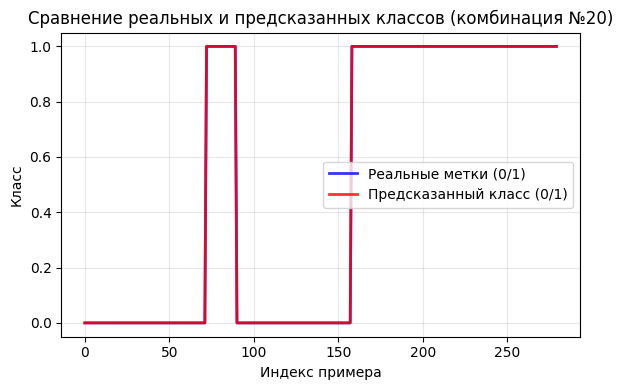

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [68]:
plot_model_by_combo_id(
    20,
    df_res_smote_2layer,
    X_smote,
    Y_smote,
    config['base']['random_state'],
    len(X_smote)
)

##### <font color='#F5DEB3'> 4.1.3 Тестирование с тремя слоями

In [69]:
hidden_opts = [ (10, 10, 10), (30, 30, 20), (32, 32, 16), (48, 48, 32), (64, 64, 32)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [100, 1000]


In [70]:
df_res_smote_3layer = train_models(
    X_smote, Y_smote,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=100 → Accuracy: 0.754 (±0.012), F1-score: 0.745 (±0.020)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.875 (±0.019), F1-score: 0.881 (±0.017)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=100 → Accuracy: 0.900 (±0.020), F1-score: 0.903 (±0.021)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.918 (±0.019), F1-score: 0.922 (±0.017)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=100 → Accuracy: 0.564 (±0.076), F1-score: 0.547 (±0.098)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.821 (±0.066), F1-score: 0.830 (±0.073)
Номер набора № 7.

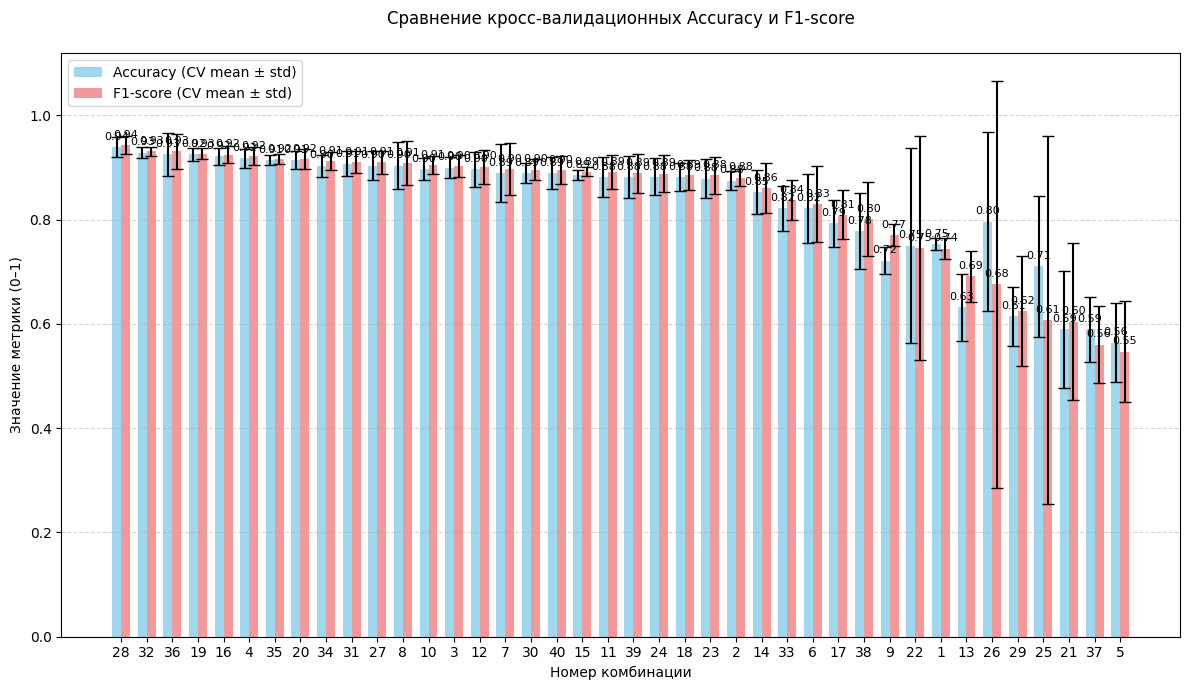

In [71]:
df_res_smote_3layer = plot_results(df_res_smote_3layer, 
                                     output_path='results/smote/hyperparameter_tuning_histograms_3layer.png')

df_res_smote_3layer.to_csv('results/smote/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [72]:
display(df_res_smote_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,28,"(48, 48, 32)",relu,lbfgs,1000,0.939286,0.018558,0.942599,0.017119
1,32,"(48, 48, 32)",tanh,lbfgs,1000,0.928571,0.010102,0.931028,0.009170
2,36,"(64, 64, 32)",relu,lbfgs,1000,0.925000,0.040877,0.930789,0.034022
3,19,"(32, 32, 16)",relu,lbfgs,100,0.925000,0.011845,0.926410,0.010996
4,16,"(30, 30, 20)",tanh,lbfgs,1000,0.921429,0.015972,0.924902,0.016596
5,4,"(10, 10, 10)",relu,lbfgs,1000,0.917857,0.018558,0.922060,0.017433
6,35,"(64, 64, 32)",relu,lbfgs,100,0.914286,0.010102,0.916651,0.009277
7,20,"(32, 32, 16)",relu,lbfgs,1000,0.914286,0.017496,0.916206,0.018858
8,34,"(64, 64, 32)",relu,adam,1000,0.903571,0.021129,0.911855,0.017200
9,31,"(48, 48, 32)",tanh,lbfgs,100,0.907143,0.023690,0.910729,0.021199


Номер выборки - 28
Гиперпараметры - hidden_layer_sizes=(48, 48, 32), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.9393 ± 0.0186, F1-score = 0.9426 ± 0.0171


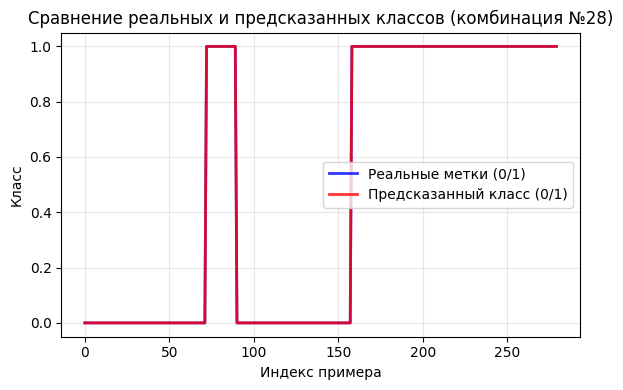

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [73]:
plot_model_by_combo_id(
    28,
    df_res_smote_3layer,
    X_smote,
    Y_smote,
    config['base']['random_state'],
    len(X_smote)
)

#### <font color='#F5DEB3'> 4.2 Балансировка класса с ADASYN

In [74]:
adasyn = ADASYN(random_state=42)

X_adasyn, Y_adasyn = adasyn.fit_resample(data_x_scaled, data_y)

##### <font color='#F5DEB3'> 4.2.1 Тестирование с одним слоем

In [75]:
hidden_opts = [(50,), (100,), (150,), (200,)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]

In [76]:
df_res_adasyn_1layer = train_models(
    X_adasyn, Y_adasyn,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.518 (±0.035), F1-score: 0.132 (±0.058)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.518 (±0.035), F1-score: 0.132 (±0.058)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.923 (±0.037), F1-score: 0.926 (±0.033)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(50,), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.923 (±0.037), F1-score: 0.926 (±0.033)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.540 (±0.033), F1-score: 0.269 (±0.092)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(50,), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.540 (±0.033), F1-score: 0.269 (±0.092)
Номер набора № 7. Гиперпараметры: hidden_layer_sizes=(50,),

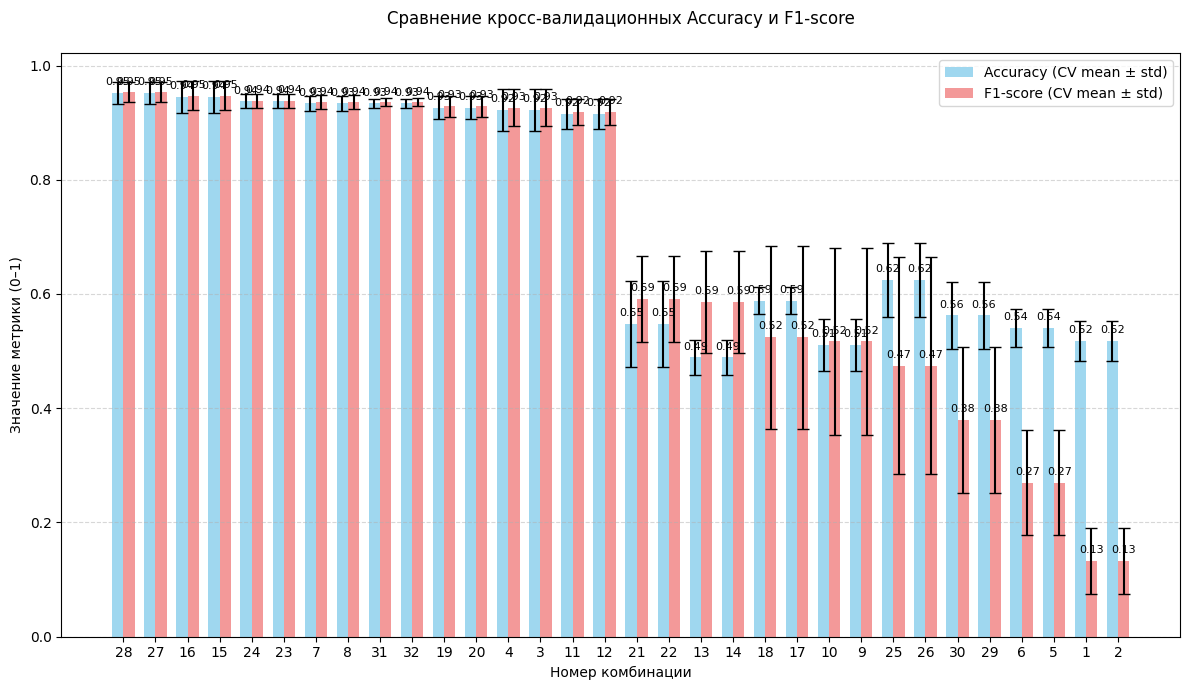

In [77]:
df_res_adasyn_1layer = plot_results(df_res_adasyn_1layer, 
                                     output_path='results/adasyn/hyperparameter_tuning_histograms_1layer.png')

df_res_adasyn_1layer.to_csv('results/adasyn/hyperparameter_tuning_results_1layer.csv', index=False, encoding='utf-8')

In [78]:
display(df_res_adasyn_1layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,28,"(200,)",relu,lbfgs,1000,0.952206,0.019104,0.953180,0.017603
1,27,"(200,)",relu,lbfgs,500,0.952206,0.019104,0.953180,0.017603
2,16,"(100,)",tanh,lbfgs,1000,0.944853,0.028240,0.946935,0.025384
3,15,"(100,)",tanh,lbfgs,500,0.944853,0.028240,0.946935,0.025384
4,24,"(150,)",tanh,lbfgs,1000,0.937500,0.012193,0.938582,0.012203
5,23,"(150,)",tanh,lbfgs,500,0.937500,0.012193,0.938582,0.012203
6,7,"(50,)",tanh,lbfgs,500,0.933824,0.012736,0.935714,0.012372
7,8,"(50,)",tanh,lbfgs,1000,0.933824,0.012736,0.935714,0.012372
8,31,"(200,)",tanh,lbfgs,500,0.933824,0.007353,0.935707,0.007186
9,32,"(200,)",tanh,lbfgs,1000,0.933824,0.007353,0.935707,0.007186


Номер выборки - 28
Гиперпараметры - hidden_layer_sizes=(200,), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.9522 ± 0.0191, F1-score = 0.9532 ± 0.0176


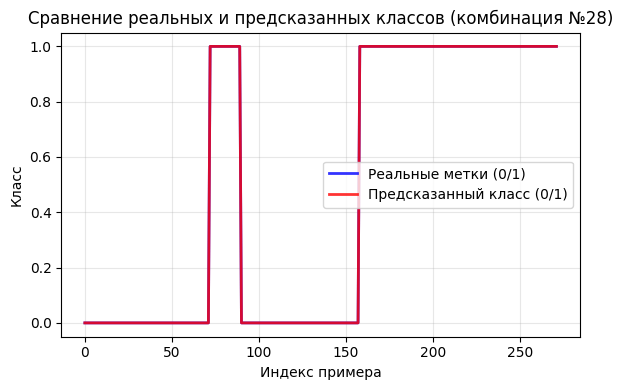

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [79]:
plot_model_by_combo_id(
    28,
    df_res_adasyn_1layer,
    X_adasyn,
    Y_adasyn,
    config['base']['random_state'],
    len(X_adasyn)
)

##### <font color='#F5DEB3'> 4.2.2 Тестирование с двумя слоями

In [80]:
hidden_opts = [(20, 10), (20, 20), (40, 30), (50, 20), (100, 50)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]


In [81]:
df_res_adasyn_2layer = train_models(
    X_adasyn, Y_adasyn,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.621 (±0.061), F1-score: 0.552 (±0.168)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.621 (±0.061), F1-score: 0.552 (±0.168)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.904 (±0.024), F1-score: 0.908 (±0.023)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.904 (±0.024), F1-score: 0.908 (±0.023)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.562 (±0.028), F1-score: 0.431 (±0.068)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(20, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.562 (±0.028), F1-score: 0.431 (±0.068)
Номер набора № 7. Гиперпараметры: hidden_

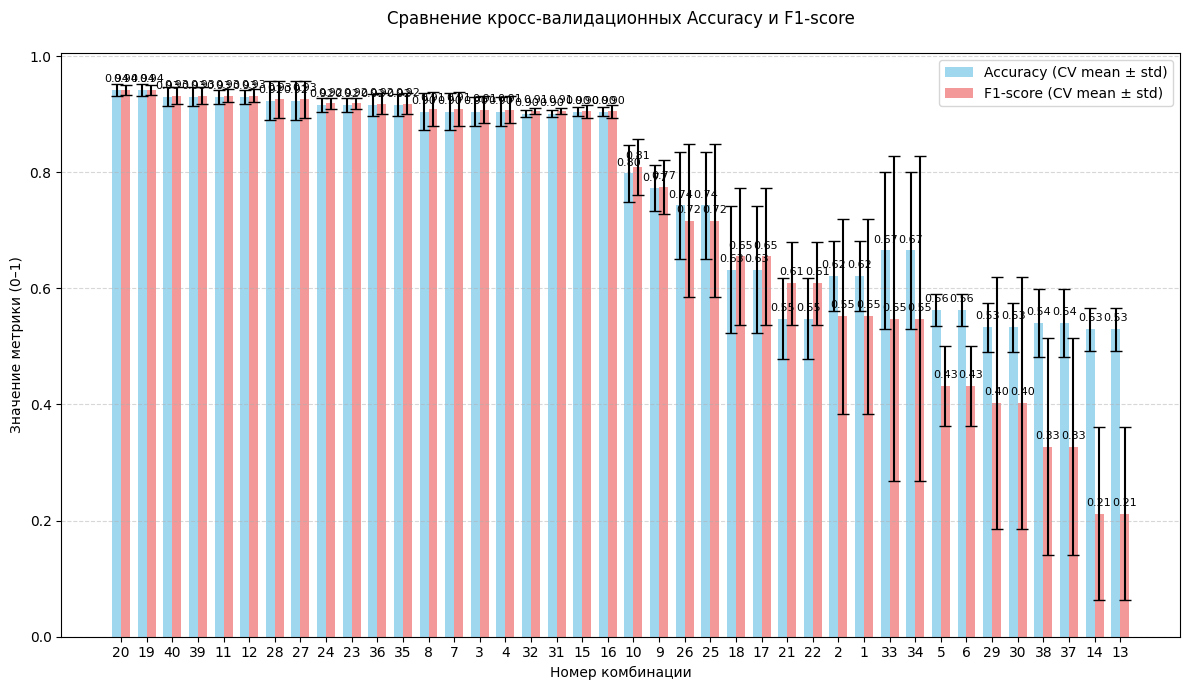

In [82]:
df_res_adasyn_2layer = plot_results(df_res_adasyn_2layer, 
                                     output_path='results/adasyn/hyperparameter_tuning_histograms_2layer.png')

df_res_adasyn_2layer.to_csv('results/adasyn/hyperparameter_tuning_results_2layer.csv', index=False, encoding='utf-8')

In [83]:
display(df_res_adasyn_2layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,20,"(40, 30)",relu,lbfgs,1000,0.941176,0.010399,0.941789,0.009088
1,19,"(40, 30)",relu,lbfgs,500,0.941176,0.010399,0.941789,0.009088
2,40,"(100, 50)",tanh,lbfgs,1000,0.930147,0.016025,0.932035,0.014885
3,39,"(100, 50)",tanh,lbfgs,500,0.930147,0.016025,0.932035,0.014885
4,11,"(20, 20)",relu,lbfgs,500,0.930147,0.012193,0.931554,0.011037
5,12,"(20, 20)",relu,lbfgs,1000,0.930147,0.012193,0.931554,0.011037
6,28,"(50, 20)",relu,lbfgs,1000,0.922794,0.033494,0.925549,0.031668
7,27,"(50, 20)",relu,lbfgs,500,0.922794,0.033494,0.925549,0.031668
8,24,"(40, 30)",tanh,lbfgs,1000,0.915441,0.012193,0.918367,0.009850
9,23,"(40, 30)",tanh,lbfgs,500,0.915441,0.012193,0.918367,0.009850


Номер выборки - 20
Гиперпараметры - hidden_layer_sizes=(40, 30), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.9412 ± 0.0104, F1-score = 0.9418 ± 0.0091


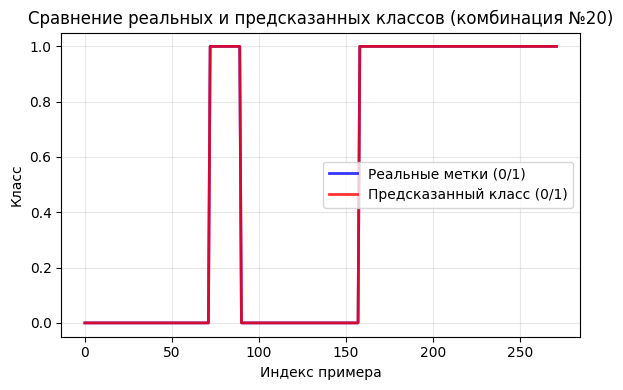

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [84]:
plot_model_by_combo_id(
    20,
    df_res_adasyn_2layer,
    X_adasyn,
    Y_adasyn,
    config['base']['random_state'],
    len(X_adasyn)
)

##### <font color='#F5DEB3'> 4.2.3 Тестирование с тремя слоями

In [85]:
hidden_opts = [ (10, 10, 10), (30, 30, 20), (32, 32, 16), (48, 48, 32), (64, 64, 32)]
act_opts = ['relu', 'tanh']
solv_opts = ['adam', 'lbfgs']
iter_opts = [500, 1000]


In [86]:
df_res_adasyn_3layer = train_models(
    X_adasyn, Y_adasyn,
    hidden_opts,
    act_opts,
    solv_opts,
    iter_opts,
    config['base']['random_state'],
    config['MLP']['model_params']['cv_folds']
)

Номер набора № 1. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=500 → Accuracy: 0.816 (±0.126), F1-score: 0.748 (±0.255)
Номер набора № 2. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=adam, max_iter=1000 → Accuracy: 0.816 (±0.126), F1-score: 0.748 (±0.255)
Номер набора № 3. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=500 → Accuracy: 0.890 (±0.016), F1-score: 0.891 (±0.018)
Номер набора № 4. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=relu, solver=lbfgs, max_iter=1000 → Accuracy: 0.890 (±0.016), F1-score: 0.891 (±0.018)
Номер набора № 5. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=500 → Accuracy: 0.515 (±0.036), F1-score: 0.377 (±0.034)
Номер набора № 6. Гиперпараметры: hidden_layer_sizes=(10, 10, 10), activation=tanh, solver=adam, max_iter=1000 → Accuracy: 0.515 (±0.036), F1-score: 0.377 (±0.034)
Номер набора № 7.

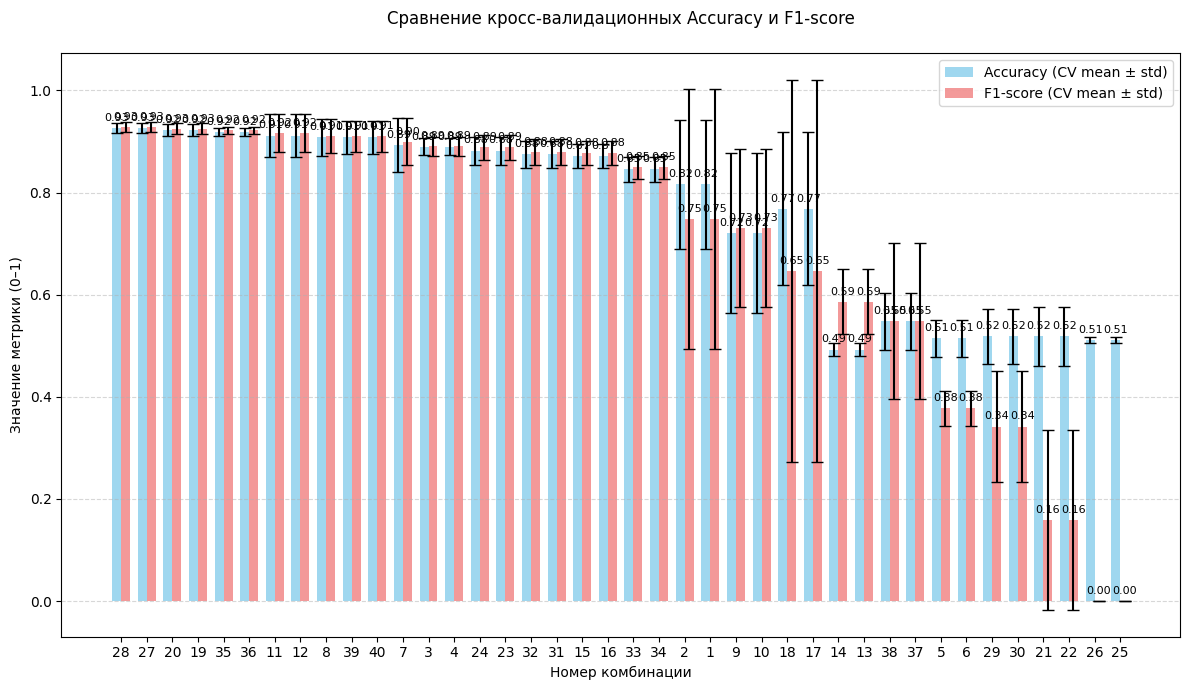

In [87]:
df_res_adasyn_3layer = plot_results(df_res_adasyn_3layer, 
                                     output_path='results/adasyn/hyperparameter_tuning_histograms_3layer.png')

df_res_adasyn_3layer.to_csv('results/adasyn/hyperparameter_tuning_results_3layer.csv', index=False, encoding='utf-8')

In [88]:
display(df_res_adasyn_3layer)

,combo_id,hidden_layer_sizes,activation,solver,max_iter,cv_mean_accuracy,cv_std_accuracy,cv_mean_f1,cv_std_f1
0,28,"(48, 48, 32)",relu,lbfgs,1000,0.926471,0.010399,0.928564,0.010127
1,27,"(48, 48, 32)",relu,lbfgs,500,0.926471,0.010399,0.928564,0.010127
2,20,"(32, 32, 16)",relu,lbfgs,1000,0.922794,0.012193,0.925336,0.011282
3,19,"(32, 32, 16)",relu,lbfgs,500,0.922794,0.012193,0.925336,0.011282
4,35,"(64, 64, 32)",relu,lbfgs,500,0.919118,0.007353,0.922017,0.006634
5,36,"(64, 64, 32)",relu,lbfgs,1000,0.919118,0.007353,0.922017,0.006634
6,11,"(30, 30, 20)",relu,lbfgs,500,0.911765,0.041595,0.916601,0.037405
7,12,"(30, 30, 20)",relu,lbfgs,1000,0.911765,0.041595,0.916601,0.037405
8,8,"(10, 10, 10)",tanh,lbfgs,1000,0.908088,0.036580,0.909966,0.033322
9,39,"(64, 64, 32)",tanh,lbfgs,500,0.908088,0.031839,0.909907,0.030500


Номер выборки - 28
Гиперпараметры - hidden_layer_sizes=(48, 48, 32), activation='relu', solver='lbfgs', max_iter=1000
Кросс-валидация: Accuracy = 0.9265 ± 0.0104, F1-score = 0.9286 ± 0.0101


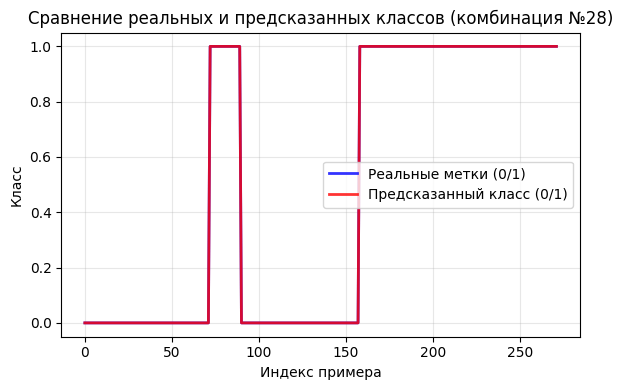

Метрики на полной выборке: Accuracy = 1.0000, F1-score = 1.0000


In [89]:
plot_model_by_combo_id(
    28,
    df_res_adasyn_3layer,
    X_adasyn,
    Y_adasyn,
    config['base']['random_state'],
    len(X_adasyn)
)

### <font color='#F5DEB3'>Итоги исследований

* **Лучший результат 1-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=5000.
Accuracy = 0.8011 ± 0.0436, F1-score = 0.5470 ± 0.1046.

* **Лучший результат 1-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(50,), activation='tanh', solver='lbfgs', max_iter=1000.    
Accuracy = 0.7955 ± 0.0161, F1-score = 0.5201 ± 0.0415.

* **Лучший результат 1-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(100,), activation='tanh', solver='lbfgs', max_iter=1000.   
Accuracy = 0.8409 ± 0.0321, F1-score = 0.6358 ± 0.0882.

* **Лучший результат 1-го слоя (SMOTE):**
Гиперпараметры - hidden_layer_sizes=(100,), activation='relu', solver='lbfgs', max_iter=10000.      
Accuracy = 0.9321 ± 0.0211, F1-score = 0.9362 ± 0.0193.

* **Лучший результат 1-го слоя (ADASYN):**
*Гиперпараметры - hidden_layer_sizes=(50,), activation='relu', solver='lbfgs', max_iter=1000.*    
*Accuracy = 0.9412 ± 0.0180, F1-score = 0.9425 ± 0.0172.*

---

* **Лучший результат 2-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=1000.
Accuracy = 0.8068 ± 0.0197, F1-score = 0.5253 ± 0.0255.

* **Лучший результат 2-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=5000.     
Accuracy = 0.8352 ± 0.0373, F1-score = 0.5574 ± 0.0465.

* **Лучший результат 2-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=5000.     
Accuracy = 0.8011 ± 0.0098, F1-score = 0.5504 ± 0.1001.

* **Лучший результат 2-го слоя (SMOTE):**
Гиперпараметры - hidden_layer_sizes=(50, 20), activation='relu', solver='lbfgs', max_iter=10000.    
Accuracy = 0.9321 ± 0.0211, F1-score = 0.9364 ± 0.0185.

* **Лучший результат 2-го слоя (ADASYN):**
Гиперпараметры - hidden_layer_sizes=(20, 10), activation='relu', solver='lbfgs', max_iter=1000.     
Accuracy = 0.9007 ± 0.0366, F1-score = 0.9041 ± 0.0371.

---

* **Лучший результат 3-го слоя (без изменений):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 10), activation='tanh', solver='lbfgs', max_iter=5000.
Accuracy = 0.7500 ± 0.0359, F1-score = 0.4063 ± 0.0233.

* **Лучший результат 3-го слоя (Sorted):**
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='relu', solver='adam', max_iter=5000.   
Accuracy = 0.8352 ± 0.0492, F1-score = 0.5858 ± 0.0430.

* **Лучший результат 3-го слоя (MinMaxScaled):**
Гиперпараметры - hidden_layer_sizes=(100, 100, 50), activation='tanh', solver='lbfgs', max_iter=5000.      
Accuracy = 0.8466 ± 0.0295, F1-score = 0.6399 ± 0.0670.

* **Лучший результат 3-го слоя (SMOTE):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 50), activation='relu', solver='lbfgs', max_iter=1000.    
Accuracy = 0.9250 ± 0.0274, F1-score = 0.9292 ± 0.0254.

* **Лучший результат 3-го слоя (ADASYN):**
Гиперпараметры - hidden_layer_sizes=(100, 50, 50), activation='relu', solver='lbfgs', max_iter=1000.    
Accuracy = 0.9228 ± 0.0335, F1-score = 0.9237 ± 0.0348.

---

**Лучший результат: 1 слой с нормализацией и балансировкой ADASYN**.

### <font color='#F5DEB3'> Optuna

#### <font color='#F5DEB3'> 4.1 Балансировка класса с SMOTE

In [90]:
import optuna

cv_folds = config['MLP']['model_params']['cv_folds']
random_state = config['base']['random_state']
n_trials = 150 

def objective(trial):
    n_neurons = trial.suggest_int('n_neurons', 10, 150)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 10, 1000, step=10)
    alpha = trial.suggest_float('alpha', 1e-4, 0.1, log=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n_neurons,),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv, scoring='f1')
    return scores.mean()

study_1 = optuna.create_study(direction='maximize')
study_1.optimize(objective, n_trials=n_trials)

print("=== Однослойная сеть ===")
print("Лучший F1 (CV):", study_1.best_value)
print("Лучшие параметры:", study_1.best_params)

[I 2026-05-01 21:00:47,180] A new study created in memory with name: no-name-bc04c6d7-d671-49f9-91aa-90e829247433
[I 2026-05-01 21:00:48,068] Trial 0 finished with value: 0.915467593099172 and parameters: {'n_neurons': 67, 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 500, 'alpha': 0.01751550974231596}. Best is trial 0 with value: 0.915467593099172.
[I 2026-05-01 21:00:48,199] Trial 1 finished with value: 0.46731411862990807 and parameters: {'n_neurons': 90, 'activation': 'relu', 'solver': 'adam', 'max_iter': 110, 'alpha': 0.014058094343792288}. Best is trial 0 with value: 0.915467593099172.
[I 2026-05-01 21:00:48,326] Trial 2 finished with value: 0.5796662765982064 and parameters: {'n_neurons': 76, 'activation': 'tanh', 'solver': 'adam', 'max_iter': 190, 'alpha': 0.006507749745693741}. Best is trial 0 with value: 0.915467593099172.
[I 2026-05-01 21:00:48,683] Trial 3 finished with value: 0.9335790335790336 and parameters: {'n_neurons': 19, 'activation': 'tanh', 'solver': 'lbfgs

=== Однослойная сеть ===
Лучший F1 (CV): 0.9626990003702333
Лучшие параметры: {'n_neurons': 63, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 470, 'alpha': 0.0006169777864236459}


In [91]:
n_trials = 150

def objective(trial):
    n1 = trial.suggest_int('n_neurons_1', 30, 80)
    n2 = trial.suggest_int('n_neurons_2', 10, 60)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 10, 1000, step=10)
    alpha = trial.suggest_float('alpha', 1e-4, 0.1, log=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, n2),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv, scoring='f1')
    return scores.mean()

study_2 = optuna.create_study(direction='maximize')
study_2.optimize(objective, n_trials=n_trials)

print("=== Двухслойная сеть ===")
print("Лучший F1 (CV):", study_2.best_value)
print("Лучшие параметры:", study_2.best_params)

[I 2026-05-01 21:02:18,551] A new study created in memory with name: no-name-9ffbe37e-27e1-4825-9b21-c6aee3ca959c
[I 2026-05-01 21:02:19,692] Trial 0 finished with value: 0.9365694642010431 and parameters: {'n_neurons_1': 57, 'n_neurons_2': 39, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 660, 'alpha': 0.002170741339157865}. Best is trial 0 with value: 0.9365694642010431.
[I 2026-05-01 21:02:20,091] Trial 1 finished with value: 0.8498697839451265 and parameters: {'n_neurons_1': 58, 'n_neurons_2': 39, 'activation': 'relu', 'solver': 'adam', 'max_iter': 240, 'alpha': 0.002061977330849306}. Best is trial 0 with value: 0.9365694642010431.
[I 2026-05-01 21:02:21,633] Trial 2 finished with value: 0.9182186234817813 and parameters: {'n_neurons_1': 36, 'n_neurons_2': 27, 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 790, 'alpha': 0.05672497157395747}. Best is trial 0 with value: 0.9365694642010431.
[I 2026-05-01 21:02:22,142] Trial 3 finished with value: 0.9330522483550602 and p

=== Двухслойная сеть ===
Лучший F1 (CV): 0.955938332698896
Лучшие параметры: {'n_neurons_1': 30, 'n_neurons_2': 19, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 600, 'alpha': 0.0035987655882033353}


In [92]:
n_trials = 250

def objective(trial):
    n1 = trial.suggest_int('n_neurons_1', 30, 70)
    n2 = trial.suggest_int('n_neurons_2', 30, 70)
    n3 = trial.suggest_int('n_neurons_3', 20, 70)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['lbfgs', 'adam'])
    max_iter = trial.suggest_int('max_iter', 10, 1000, step=10)
    alpha = trial.suggest_float('alpha', 1e-4, 0.1, log=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, n2, n3),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv, scoring='f1')
    return scores.mean()

study_3 = optuna.create_study(direction='maximize')
study_3.optimize(objective, n_trials=n_trials)

print("=== Трёхслойная сеть ===")
print("Лучший F1 (CV):", study_3.best_value)
print("Лучшие параметры:", study_3.best_params)

[I 2026-05-01 21:04:35,320] A new study created in memory with name: no-name-310d4195-1711-4da2-abd0-162c86e81908
[I 2026-05-01 21:04:35,434] Trial 0 finished with value: 0.6215393133997785 and parameters: {'n_neurons_1': 69, 'n_neurons_2': 45, 'n_neurons_3': 33, 'activation': 'relu', 'solver': 'adam', 'max_iter': 40, 'alpha': 0.0019171627300763375}. Best is trial 0 with value: 0.6215393133997785.
[I 2026-05-01 21:04:35,778] Trial 1 finished with value: 0.6642348144709384 and parameters: {'n_neurons_1': 66, 'n_neurons_2': 34, 'n_neurons_3': 59, 'activation': 'tanh', 'solver': 'adam', 'max_iter': 180, 'alpha': 0.0037124736405723833}. Best is trial 1 with value: 0.6642348144709384.
[I 2026-05-01 21:04:36,613] Trial 2 finished with value: 0.9276587301587302 and parameters: {'n_neurons_1': 68, 'n_neurons_2': 45, 'n_neurons_3': 56, 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 180, 'alpha': 0.0002424750236643873}. Best is trial 2 with value: 0.9276587301587302.
[I 2026-05-01 21:04:37

=== Трёхслойная сеть ===
Лучший F1 (CV): 0.9592642613672905
Лучшие параметры: {'n_neurons_1': 30, 'n_neurons_2': 51, 'n_neurons_3': 49, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 670, 'alpha': 0.012691448429704275}


In [105]:
def plot_train_test_predictions_cv(
    X_train, y_train,        # обучающая выборка (например, SMOTE)
    X_test, y_test,          # тестовая выборка (исходные данные)
    parameters,              # словарь гиперпараметров MLPClassifier
    cv_folds=4,
    random_state=42,
    title_prefix="",
    n_show=None,
    output_path=None,
    dpi=600
):
    for key, value in parameters.items():
        print(f"  {key}: {value}")
    print()

    mlp_cv = MLPClassifier(**parameters, random_state=random_state)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    scores_acc = cross_val_score(mlp_cv, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(mlp_cv, X_train, y_train, cv=cv, scoring='f1')

    acc_mean, acc_std = scores_acc.mean(), scores_acc.std()
    f1_mean, f1_std = scores_f1.mean(), scores_f1.std()

    print(f"Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"F1-score : {f1_mean:.4f} ± {f1_std:.4f}")

    mlp_full = MLPClassifier(**parameters, random_state=random_state)
    mlp_full.fit(X_train, y_train)
    y_pred = mlp_full.predict(X_test)

    acc_test = accuracy_score(y_test, y_pred)
    f1_test = f1_score(y_test, y_pred, average='binary', zero_division=0)
    print(f"Метрики на тестовой (исходной) выборке: Accuracy : {acc_test:.4f}, F1-score : {f1_test:.4f}")

    if n_show is None:
        n_show = len(y_test)
    else:
        n_show = min(n_show, len(y_test))

    indices = np.arange(n_show)
    plt.figure(figsize=(14, 6))
    plt.plot(indices, y_test[:n_show], label='Реальные метки',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n_show], label='Предсказанные',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс')
    plt.title(f'{title_prefix}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=dpi, bbox_inches='tight')
    plt.show()


def prepare_params(params, n_layers):
    """Извлекает параметры из словаря Optuna и формирует hidden_layer_sizes."""
    model_params = {
        'activation': params['activation'],
        'solver': params['solver'],
        'max_iter': params['max_iter'],
        'alpha': params['alpha'],
    }
    if n_layers == 1:
        model_params['hidden_layer_sizes'] = (params['n_neurons'],)
    elif n_layers == 2:
        model_params['hidden_layer_sizes'] = (params['n_neurons_1'], params['n_neurons_2'])
    elif n_layers == 3:
        model_params['hidden_layer_sizes'] = (params['n_neurons_1'], params['n_neurons_2'], params['n_neurons_3'])
    return model_params

  activation: relu
  solver: lbfgs
  max_iter: 470
  alpha: 0.0006169777864236459
  hidden_layer_sizes: (63,)

Accuracy : 0.9607 ± 0.0234
F1-score : 0.9627 ± 0.0222
Метрики на тестовой (исходной) выборке: Accuracy : 1.0000, F1-score : 1.0000


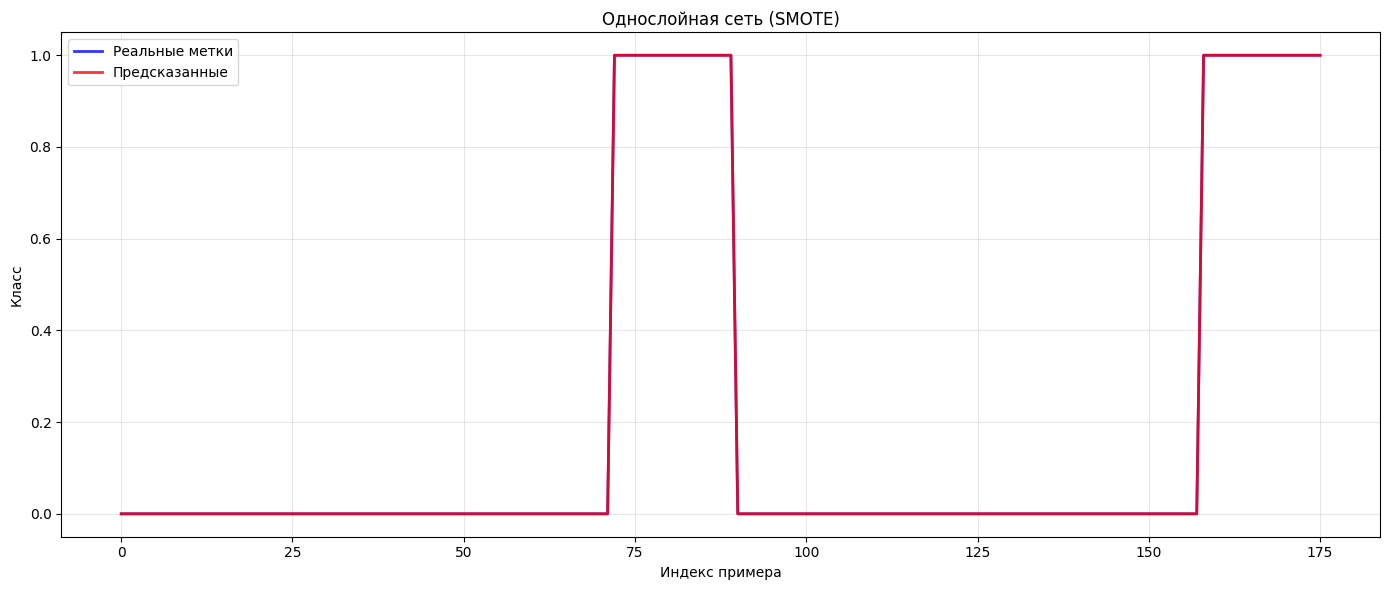

  activation: relu
  solver: lbfgs
  max_iter: 600
  alpha: 0.0035987655882033353
  hidden_layer_sizes: (30, 19)

Accuracy : 0.9536 ± 0.0186
F1-score : 0.9559 ± 0.0173
Метрики на тестовой (исходной) выборке: Accuracy : 1.0000, F1-score : 1.0000


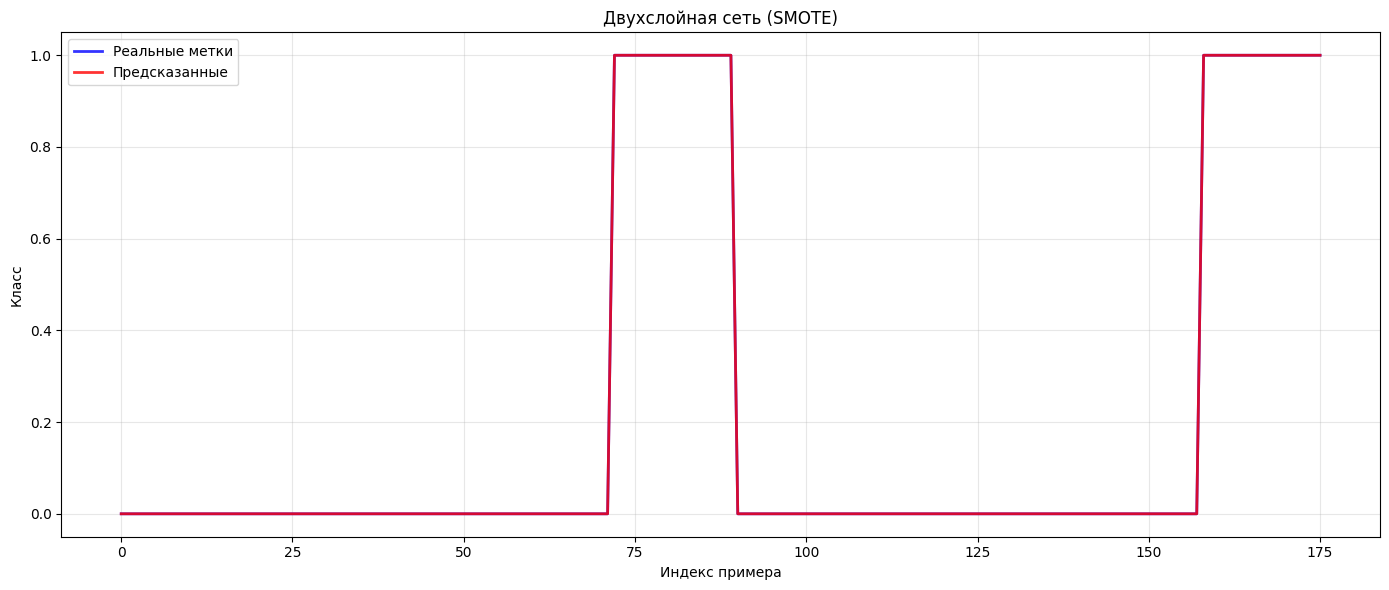

  activation: relu
  solver: lbfgs
  max_iter: 670
  alpha: 0.012691448429704275
  hidden_layer_sizes: (30, 51, 49)

Accuracy : 0.9571 ± 0.0202
F1-score : 0.9593 ± 0.0186
Метрики на тестовой (исходной) выборке: Accuracy : 1.0000, F1-score : 1.0000


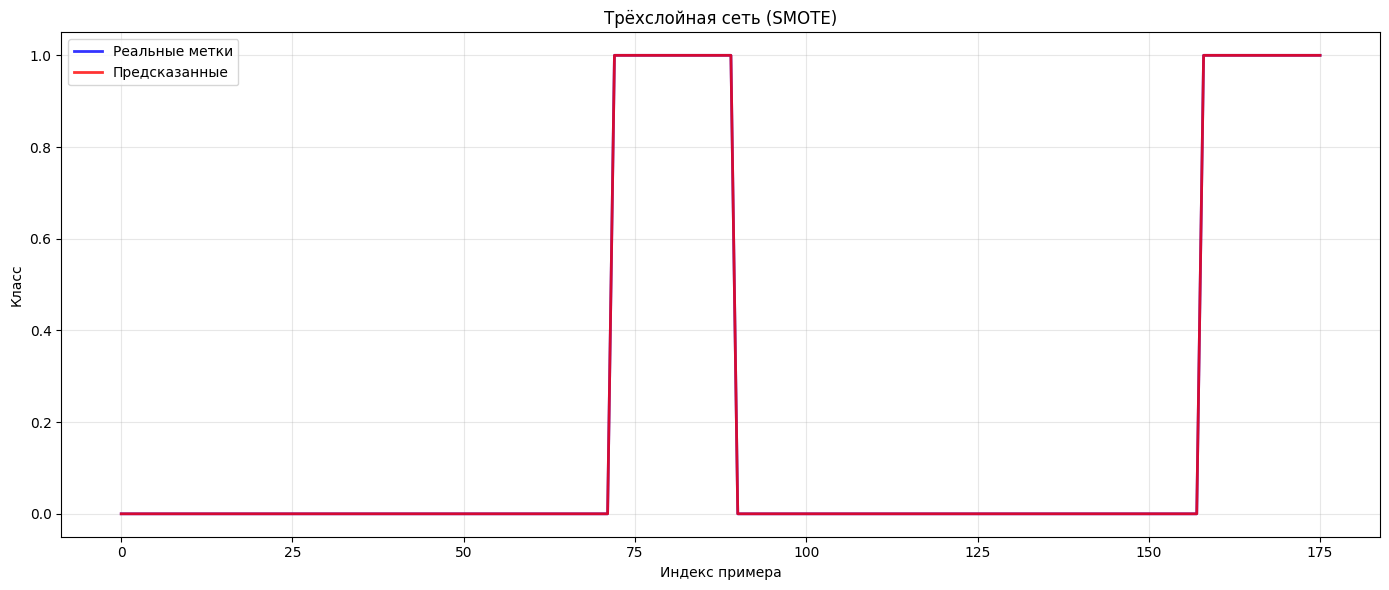

In [106]:
best_params_1 = study_1.best_params
best_params_2 = study_2.best_params
best_params_3 = study_3.best_params

params1 = prepare_params(best_params_1, 1)
params2 = prepare_params(best_params_2, 2)
params3 = prepare_params(best_params_3, 3)

# Однослойная
plot_train_test_predictions_cv(
    X_train=X_smote, y_train=Y_smote,
    X_test=data_x_scaled, y_test=data_y,
    parameters=params1,
    random_state=random_state,
    title_prefix="Однослойная сеть (SMOTE)"
)

# Двухслойная
plot_train_test_predictions_cv(
    X_train=X_smote, y_train=Y_smote,
    X_test=data_x_scaled, y_test=data_y,
    parameters=params2,
    random_state=random_state,
    title_prefix="Двухслойная сеть (SMOTE)"
)

# Трёхслойная
plot_train_test_predictions_cv(
    X_train=X_smote, y_train=Y_smote,
    X_test=data_x_scaled, y_test=data_y,
    parameters=params3,
    random_state=random_state,
    title_prefix="Трёхслойная сеть (SMOTE)"
)

In [ ]:
def evaluate_and_save_model(
    model_name,            
    parameters,            
    X_train, y_train,      
    X_test, y_test,        
    cv_folds=4,
    random_state=42,
    output_file='best_models_results.txt'
):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    mlp_cv = MLPClassifier(**parameters, random_state=random_state)

    scores_acc = cross_val_score(mlp_cv, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1  = cross_val_score(mlp_cv, X_train, y_train, cv=cv, scoring='f1')

    acc_cv = scores_acc.mean()
    acc_std = scores_acc.std()
    f1_cv  = scores_f1.mean()
    f1_std = scores_f1.std()

    mlp_final = MLPClassifier(**parameters, random_state=random_state)
    mlp_final.fit(X_train, y_train)
    y_pred = mlp_final.predict(X_test)

    acc_test = accuracy_score(y_test, y_pred)
    f1_test  = f1_score(y_test, y_pred, average='binary', zero_division=0)

    # Запись в файл
    with open(output_file, 'a', encoding='utf-8') as f:
        f.write(f"{model_name}\n")
        f.write("Гиперпараметры:\n")
        for key, value in parameters.items():
            f.write(f"  {key}: {value}\n")
        f.write("Кросс-валидация (на сбалансированных данных):\n")
        f.write(f"  Accuracy : {acc_cv:.4f} ± {acc_std:.4f}\n")
        f.write(f"  F1-score : {f1_cv:.4f} ± {f1_std:.4f}\n")
        f.write("Тест на исходных (несбалансированных) данных:\n")
        f.write(f"  Accuracy : {acc_test:.4f}\n")
        f.write(f"  F1-score : {f1_test:.4f}\n")
        f.write("\n" + "-"*50 + "\n\n")

    return {
        'acc_cv': acc_cv, 'acc_std': acc_std,
        'f1_cv': f1_cv, 'f1_std': f1_std,
        'acc_test': acc_test, 'f1_test': f1_test
    }

output_file = 'results/best_models_optuna_SMOTE.txt'

res1 = evaluate_and_save_model(
    "Однослойная сеть (SMOTE)", params1,
    X_smote, Y_smote, data_x_scaled, data_y,
    cv_folds=cv_folds, random_state=random_state, output_file=output_file
)

res2 = evaluate_and_save_model(
    "Двухслойная сеть (SMOTE)", params2,
    X_smote, Y_smote, data_x_scaled, data_y,
    cv_folds=cv_folds, random_state=random_state, output_file=output_file
)

res3 = evaluate_and_save_model(
    "Трёхслойная сеть (SMOTE)", params3,
    X_smote, Y_smote, data_x_scaled, data_y,
    cv_folds=cv_folds, random_state=random_state, output_file=output_file
)

print(f"Результаты сохранены в файл: {output_file}")

Результаты сохранены в файл: results/best_models_optuna_SMOTE.txt


#### <font color='#F5DEB3'> 4.2 Балансировка класса с ADASYN

In [110]:
n_trials = 150 

def objective(trial):
    n_neurons = trial.suggest_int('n_neurons', 10, 150)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 10, 1000, step=10)
    alpha = trial.suggest_float('alpha', 1e-4, 0.1, log=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n_neurons,),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv, scoring='f1')
    return scores.mean()

study_1 = optuna.create_study(direction='maximize')
study_1.optimize(objective, n_trials=n_trials)

print("=== Однослойная сеть ===")
print("Лучший F1 (CV):", study_1.best_value)
print("Лучшие параметры:", study_1.best_params)

[I 2026-05-01 22:44:28,460] A new study created in memory with name: no-name-070210d6-0e71-4080-9789-7f220f59be7c
[I 2026-05-01 22:44:29,589] Trial 0 finished with value: 0.9429533724083632 and parameters: {'n_neurons': 125, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 830, 'alpha': 0.004845127012413363}. Best is trial 0 with value: 0.9429533724083632.
[I 2026-05-01 22:44:30,037] Trial 1 finished with value: 0.9266304347826086 and parameters: {'n_neurons': 128, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 850, 'alpha': 0.0002443733556180291}. Best is trial 0 with value: 0.9429533724083632.
[I 2026-05-01 22:44:30,386] Trial 2 finished with value: 0.9294362562110803 and parameters: {'n_neurons': 63, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 380, 'alpha': 0.00013006388269108814}. Best is trial 0 with value: 0.9429533724083632.
[I 2026-05-01 22:44:30,446] Trial 3 finished with value: 0.07291666666666667 and parameters: {'n_neurons': 55, 'activation': 'tanh', 'sol

=== Однослойная сеть ===
Лучший F1 (CV): 0.9605590062111802
Лучшие параметры: {'n_neurons': 66, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 230, 'alpha': 0.0032129369904992234}


In [111]:
n_trials = 150

def objective(trial):
    n1 = trial.suggest_int('n_neurons_1', 30, 80)
    n2 = trial.suggest_int('n_neurons_2', 10, 60)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 10, 1000, step=10)
    alpha = trial.suggest_float('alpha', 1e-4, 0.1, log=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, n2),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv, scoring='f1')
    return scores.mean()

study_2 = optuna.create_study(direction='maximize')
study_2.optimize(objective, n_trials=n_trials)

print("=== Двухслойная сеть ===")
print("Лучший F1 (CV):", study_2.best_value)
print("Лучшие параметры:", study_2.best_params)

[I 2026-05-01 22:45:49,028] A new study created in memory with name: no-name-5d387bf2-3668-49ae-b261-d3464f22f5ef
[I 2026-05-01 22:45:49,469] Trial 0 finished with value: 0.8308278869267032 and parameters: {'n_neurons_1': 36, 'n_neurons_2': 20, 'activation': 'relu', 'solver': 'adam', 'max_iter': 920, 'alpha': 0.00011513680984729639}. Best is trial 0 with value: 0.8308278869267032.
[I 2026-05-01 22:45:50,485] Trial 1 finished with value: 0.9075 and parameters: {'n_neurons_1': 31, 'n_neurons_2': 51, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 940, 'alpha': 0.0028288725670534264}. Best is trial 1 with value: 0.9075.
[I 2026-05-01 22:45:50,600] Trial 2 finished with value: 0.5435621750669559 and parameters: {'n_neurons_1': 30, 'n_neurons_2': 45, 'activation': 'relu', 'solver': 'adam', 'max_iter': 130, 'alpha': 0.005642160213406248}. Best is trial 1 with value: 0.9075.
[I 2026-05-01 22:45:50,968] Trial 3 finished with value: 0.9015103338632751 and parameters: {'n_neurons_1': 65, 'n

=== Двухслойная сеть ===
Лучший F1 (CV): 0.9498861455176069
Лучшие параметры: {'n_neurons_1': 57, 'n_neurons_2': 30, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 190, 'alpha': 0.032059388540224526}


In [112]:
n_trials = 250

def objective(trial):
    n1 = trial.suggest_int('n_neurons_1', 30, 70)
    n2 = trial.suggest_int('n_neurons_2', 30, 70)
    n3 = trial.suggest_int('n_neurons_3', 20, 70)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['lbfgs', 'adam'])
    max_iter = trial.suggest_int('max_iter', 10, 1000, step=10)
    alpha = trial.suggest_float('alpha', 1e-4, 0.1, log=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    mlp = MLPClassifier(
        hidden_layer_sizes=(n1, n2, n3),
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        random_state=random_state
    )

    scores = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv, scoring='f1')
    return scores.mean()

study_3 = optuna.create_study(direction='maximize')
study_3.optimize(objective, n_trials=n_trials)

print("=== Трёхслойная сеть ===")
print("Лучший F1 (CV):", study_3.best_value)
print("Лучшие параметры:", study_3.best_params)

[I 2026-05-01 22:47:02,027] A new study created in memory with name: no-name-750cf43f-c25c-4b4f-908b-a8d0158c7ada
[I 2026-05-01 22:47:02,883] Trial 0 finished with value: 0.9429533724083632 and parameters: {'n_neurons_1': 70, 'n_neurons_2': 37, 'n_neurons_3': 35, 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 360, 'alpha': 0.0002677978905241824}. Best is trial 0 with value: 0.9429533724083632.
[I 2026-05-01 22:47:04,991] Trial 1 finished with value: 0.9404047058881606 and parameters: {'n_neurons_1': 53, 'n_neurons_2': 49, 'n_neurons_3': 54, 'activation': 'relu', 'solver': 'lbfgs', 'max_iter': 780, 'alpha': 0.0036292618278781184}. Best is trial 0 with value: 0.9429533724083632.
[I 2026-05-01 22:47:05,591] Trial 2 finished with value: 0.8932577372875881 and parameters: {'n_neurons_1': 44, 'n_neurons_2': 59, 'n_neurons_3': 63, 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 130, 'alpha': 0.0016599323715740908}. Best is trial 0 with value: 0.9429533724083632.
[I 2026-05-01 22:47

=== Трёхслойная сеть ===
Лучший F1 (CV): 0.9568189186268505
Лучшие параметры: {'n_neurons_1': 60, 'n_neurons_2': 60, 'n_neurons_3': 56, 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 540, 'alpha': 0.0013197827316423424}


  activation: relu
  solver: lbfgs
  max_iter: 230
  alpha: 0.0032129369904992234
  hidden_layer_sizes: (66,)

Accuracy : 0.9596 ± 0.0241
F1-score : 0.9606 ± 0.0234
Метрики на тестовой (исходной) выборке: Accuracy : 1.0000, F1-score : 1.0000


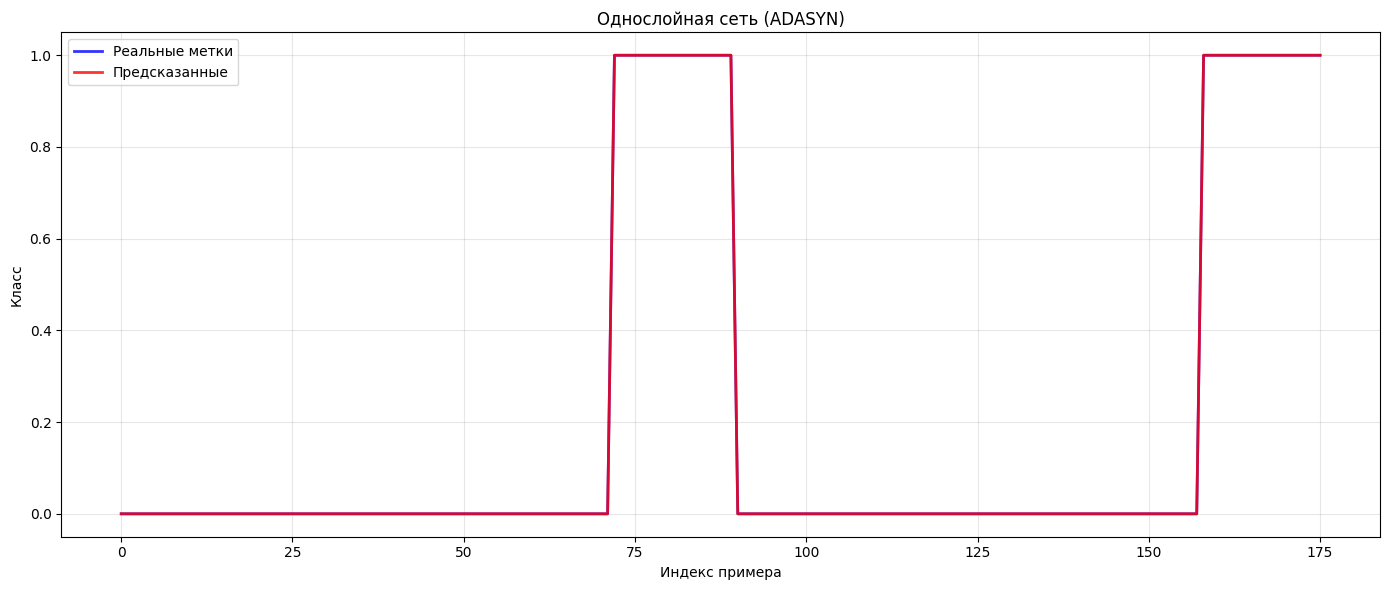

  activation: relu
  solver: lbfgs
  max_iter: 190
  alpha: 0.032059388540224526
  hidden_layer_sizes: (57, 30)

Accuracy : 0.9485 ± 0.0164
F1-score : 0.9499 ± 0.0153
Метрики на тестовой (исходной) выборке: Accuracy : 1.0000, F1-score : 1.0000


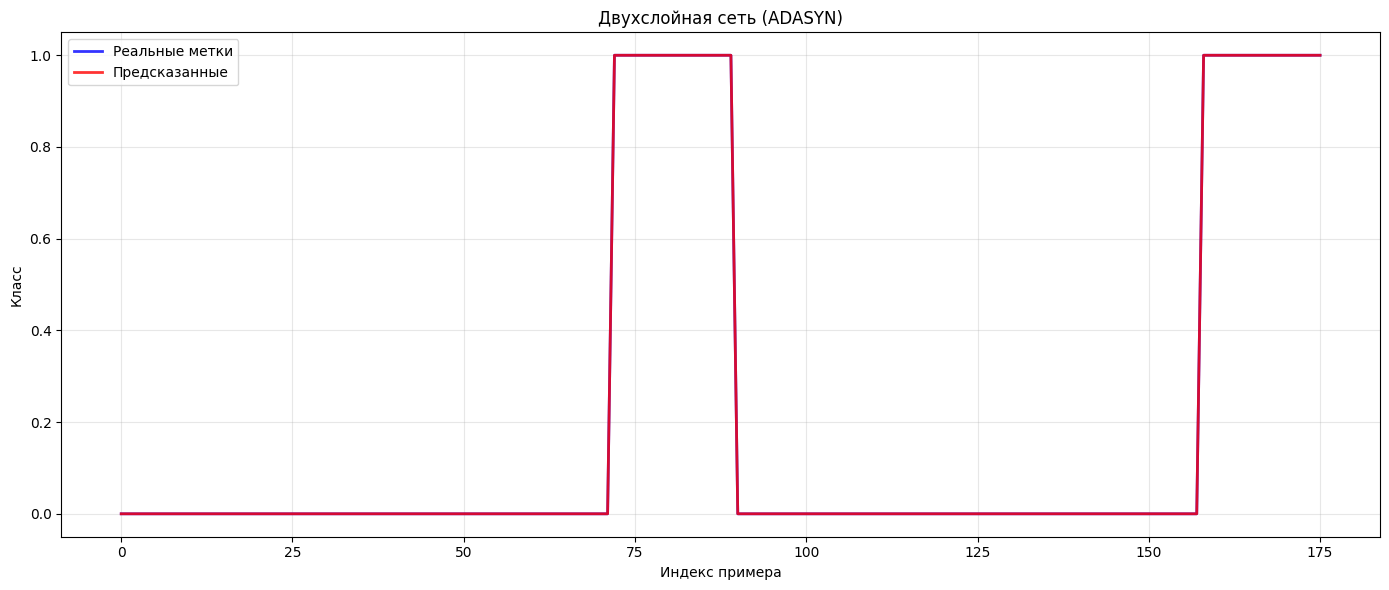

  activation: tanh
  solver: lbfgs
  max_iter: 540
  alpha: 0.0013197827316423424
  hidden_layer_sizes: (60, 60, 56)

Accuracy : 0.9559 ± 0.0180
F1-score : 0.9568 ± 0.0167
Метрики на тестовой (исходной) выборке: Accuracy : 1.0000, F1-score : 1.0000


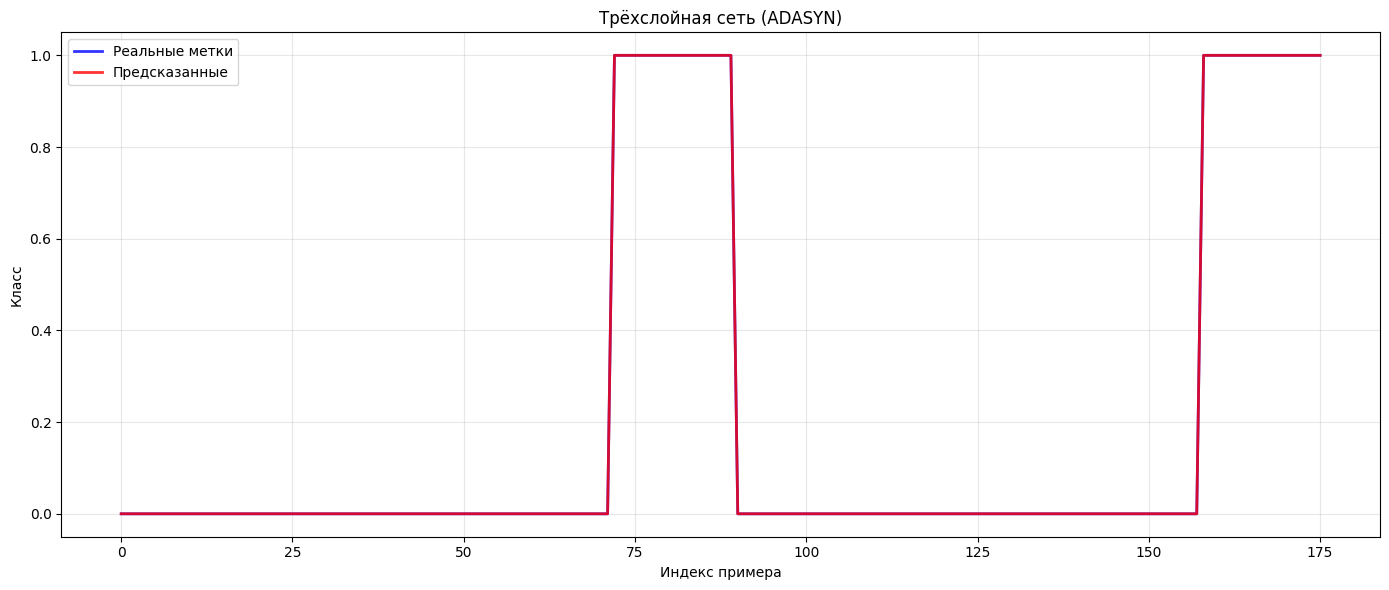

In [113]:
best_params_1 = study_1.best_params
best_params_2 = study_2.best_params
best_params_3 = study_3.best_params

params1 = prepare_params(best_params_1, 1)
params2 = prepare_params(best_params_2, 2)
params3 = prepare_params(best_params_3, 3)

# Однослойная
plot_train_test_predictions_cv(
    X_train=X_adasyn, y_train=Y_adasyn,
    X_test=data_x_scaled, y_test=data_y,
    parameters=params1,
    random_state=random_state,
    title_prefix="Однослойная сеть (ADASYN)"
)

# Двухслойная
plot_train_test_predictions_cv(
    X_train=X_adasyn, y_train=Y_adasyn,
    X_test=data_x_scaled, y_test=data_y,
    parameters=params2,
    random_state=random_state,
    title_prefix="Двухслойная сеть (ADASYN)"
)

# Трёхслойная
plot_train_test_predictions_cv(
    X_train=X_adasyn, y_train=Y_adasyn,
    X_test=data_x_scaled, y_test=data_y,
    parameters=params3,
    random_state=random_state,
    title_prefix="Трёхслойная сеть (ADASYN)"
)

In [ ]:
output_file = 'results/best_models_optuna_ADASYN.txt'

res1 = evaluate_and_save_model(
    "Однослойная сеть (ADASYN)", params1,
    X_adasyn, Y_adasyn, data_x_scaled, data_y,
    cv_folds=cv_folds, random_state=random_state, output_file=output_file
)

res2 = evaluate_and_save_model(
    "Двухслойная сеть (ADASYN)", params2,
    X_adasyn, Y_adasyn, data_x_scaled, data_y,
    cv_folds=cv_folds, random_state=random_state, output_file=output_file
)

res3 = evaluate_and_save_model(
    "Трёхслойная сеть (ADASYN)", params3,
    X_adasyn, Y_adasyn, data_x_scaled, data_y,
    cv_folds=cv_folds, random_state=random_state, output_file=output_file
)

print(f"Результаты сохранены в файл: {output_file}")

Результаты сохранены в файл: results/best_models_optuna_ADASYN.txt
